In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 1488
DATA_DIR = Path("/kaggle/input/competitions/hms-harmful-brain-activity-classification")

LABEL_COLS = [
    "seizure_vote",
    "lpd_vote",
    "gpd_vote",
    "lrda_vote",
    "grda_vote",
    "other_vote",
]

CLASS_NAMES = [col.replace("_vote", "") for col in LABEL_COLS]

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory was not found: {DATA_DIR}. "
        "Run this notebook on Kaggle with the competition dataset attached."
    )

print(f"Using data directory: {DATA_DIR}")
print(f"Classes: {CLASS_NAMES}")

Using data directory: /kaggle/input/competitions/hms-harmful-brain-activity-classification
Classes: ['seizure', 'lpd', 'gpd', 'lrda', 'grda', 'other']


In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")
print(f"sample submission shape: {sample_submission.shape}")

train shape: (106800, 15)
test shape: (1, 3)
sample submission shape: (1, 7)


In [3]:
display(train.head())
display(test.head())
display(sample_submission.head())

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0


,spectrogram_id,eeg_id,patient_id
0,853520,3911565283,6885


,eeg_id,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,3911565283,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667


In [4]:
basic_counts = pd.Series(
    {
        "train rows": len(train),
        "test rows shown by Kaggle": len(test),
        "unique eeg_id": train["eeg_id"].nunique(),
        "unique spectrogram_id": train["spectrogram_id"].nunique(),
        "unique patient_id": train["patient_id"].nunique(),
    },
    name="count",
).to_frame()

display(basic_counts)

,count
train rows,106800
test rows shown by Kaggle,1
unique eeg_id,17089
unique spectrogram_id,11138
unique patient_id,1950


In [5]:
for folder_name in ["train_eegs", "train_spectrograms", "test_eegs", "test_spectrograms"]:
    folder = DATA_DIR / folder_name
    files = sorted(folder.glob("*.parquet"))
    print(f"{folder_name}: {len(files)} parquet files")
    print("first examples:", [file.name for file in files[:5]])
    print()

train_eegs: 17300 parquet files
first examples: ['1000913311.parquet', '1001369401.parquet', '1001487592.parquet', '1001717358.parquet', '1002136740.parquet']

train_spectrograms: 11138 parquet files
first examples: ['1000086677.parquet', '1000189855.parquet', '1000317312.parquet', '1000381196.parquet', '1000493950.parquet']

test_eegs: 1 parquet files
first examples: ['3911565283.parquet']

test_spectrograms: 1 parquet files
first examples: ['853520.parquet']



## Raw EEG Example


In [6]:
example_row = train.iloc[0]

example_eeg_id = int(example_row["eeg_id"])
example_spectrogram_id = int(example_row["spectrogram_id"])

eeg_path = DATA_DIR / "train_eegs" / f"{example_eeg_id}.parquet"
spectrogram_path = DATA_DIR / "train_spectrograms" / f"{example_spectrogram_id}.parquet"

print("Example metadata row:")
display(example_row.to_frame("value"))

print("Raw EEG file:", eeg_path)
print("Spectrogram file:", spectrogram_path)

Example metadata row:


,value
eeg_id,1628180742
eeg_sub_id,0
eeg_label_offset_seconds,0.0
spectrogram_id,353733
spectrogram_sub_id,0
spectrogram_label_offset_seconds,0.0
label_id,127492639
patient_id,42516
expert_consensus,Seizure
seizure_vote,3


Raw EEG file: /kaggle/input/competitions/hms-harmful-brain-activity-classification/train_eegs/1628180742.parquet
Spectrogram file: /kaggle/input/competitions/hms-harmful-brain-activity-classification/train_spectrograms/353733.parquet


In [7]:
eeg = pd.read_parquet(eeg_path)

print("EEG shape:", eeg.shape)
print("EEG channels:", eeg.columns.tolist())

display(eeg.head())

EEG shape: (18000, 20)
EEG channels: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']


,Fp1,F3,C3,P3,F7,T3,T5,O1,Fz,Cz,Pz,Fp2,F4,C4,P4,F8,T4,T6,O2,EKG
0,-80.519997,-70.540001,-80.110001,-108.750000,-120.330002,-88.620003,-101.750000,-104.489998,-99.129997,-90.389999,-97.040001,-77.989998,-88.830002,-112.120003,-108.110001,-95.949997,-98.360001,-121.730003,-106.449997,7.920000
1,-80.449997,-70.330002,-81.760002,-107.669998,-120.769997,-90.820000,-104.260002,-99.730003,-99.070000,-92.290001,-96.019997,-84.500000,-84.989998,-115.610001,-103.860001,-97.470001,-89.290001,-115.500000,-102.059998,29.219999
2,-80.209999,-75.870003,-82.050003,-106.010002,-117.500000,-87.489998,-99.589996,-96.820000,-119.680000,-99.360001,-91.110001,-99.440002,-104.589996,-127.529999,-113.349998,-95.870003,-96.019997,-123.879997,-105.790001,45.740002
3,-84.709999,-75.339996,-87.480003,-108.970001,-121.410004,-94.750000,-105.370003,-100.279999,-113.839996,-102.059998,-95.040001,-99.230003,-101.220001,-125.769997,-111.889999,-97.459999,-97.180000,-128.940002,-109.889999,83.870003
4,-90.570000,-80.790001,-93.000000,-113.870003,-129.960007,-102.860001,-118.599998,-101.099998,-107.660004,-102.339996,-98.510002,-95.300003,-88.930000,-115.639999,-99.800003,-97.500000,-88.730003,-114.849998,-100.250000,97.769997


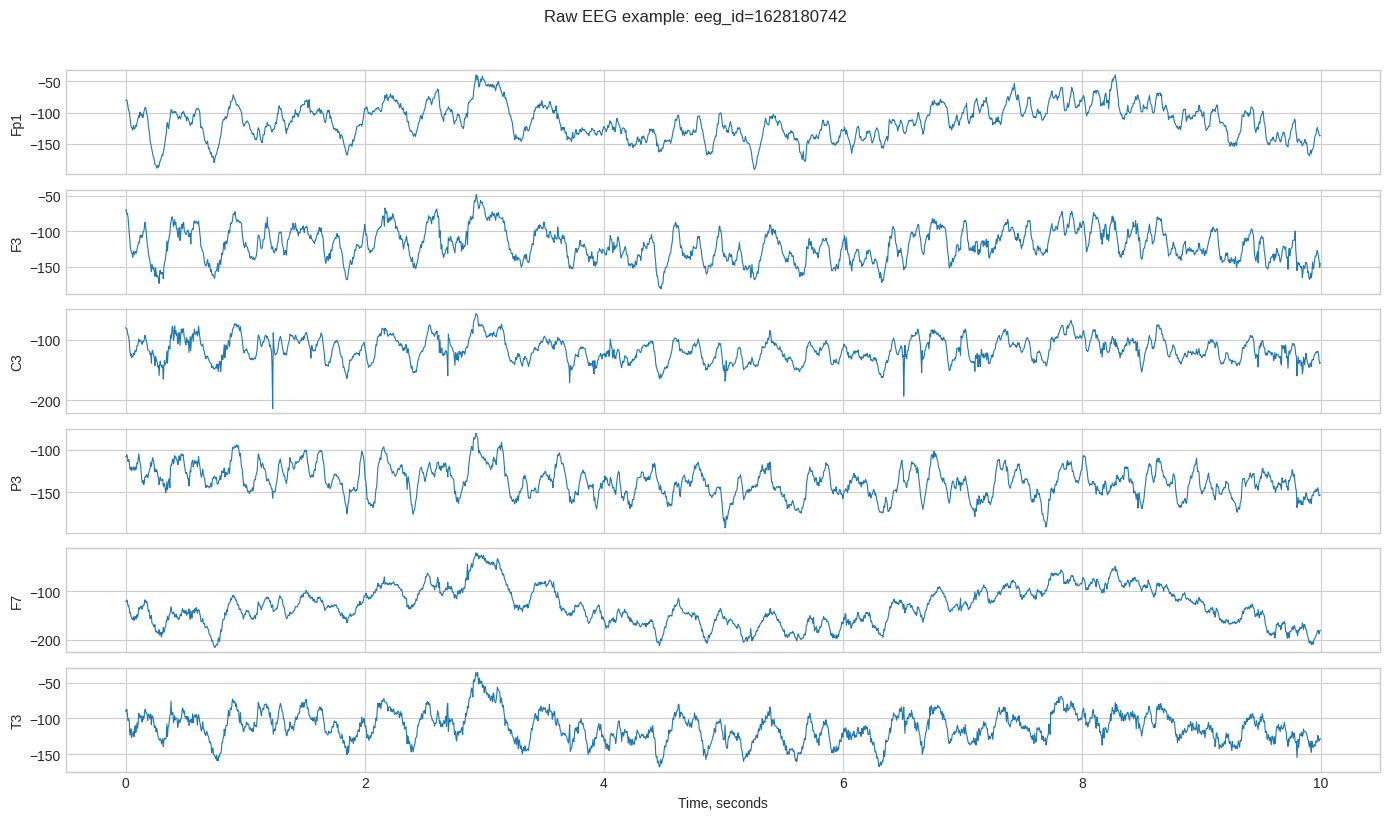

In [ ]:
EEG_SAMPLING_RATE = 200 

channels_to_plot = eeg.columns[:6].tolist()
n_points = min(2000, len(eeg))
time_seconds = np.arange(n_points) / EEG_SAMPLING_RATE

fig, axes = plt.subplots(len(channels_to_plot), 1, figsize=(14, 8), sharex=True)

for ax, channel in zip(axes, channels_to_plot):
    ax.plot(time_seconds, eeg[channel].iloc[:n_points].values, linewidth=0.8)
    ax.set_ylabel(channel)

axes[-1].set_xlabel("Time, seconds")
fig.suptitle(f"Raw EEG example: eeg_id={example_eeg_id}", y=1.02)
plt.tight_layout()
plt.show()


## Spectrogram Example

In [9]:
spectrogram = pd.read_parquet(spectrogram_path)

print("Spectrogram shape:", spectrogram.shape)
print("First columns:", spectrogram.columns[:15].tolist())
print("Last columns:", spectrogram.columns[-15:].tolist())

display(spectrogram.head())

Spectrogram shape: (320, 401)
First columns: ['time', 'LL_0.59', 'LL_0.78', 'LL_0.98', 'LL_1.17', 'LL_1.37', 'LL_1.56', 'LL_1.76', 'LL_1.95', 'LL_2.15', 'LL_2.34', 'LL_2.54', 'LL_2.73', 'LL_2.93', 'LL_3.13']
Last columns: ['RP_17.19', 'RP_17.38', 'RP_17.58', 'RP_17.77', 'RP_17.97', 'RP_18.16', 'RP_18.36', 'RP_18.55', 'RP_18.75', 'RP_18.95', 'RP_19.14', 'RP_19.34', 'RP_19.53', 'RP_19.73', 'RP_19.92']


,time,LL_0.59,LL_0.78,LL_0.98,LL_1.17,LL_1.37,LL_1.56,LL_1.76,LL_1.95,LL_2.15,LL_2.34,LL_2.54,LL_2.73,LL_2.93,LL_3.13,LL_3.32,LL_3.52,LL_3.71,LL_3.91,LL_4.1,LL_4.3,LL_4.49,LL_4.69,LL_4.88,LL_5.08,LL_5.27,LL_5.47,LL_5.66,LL_5.86,LL_6.05,LL_6.25,LL_6.45,LL_6.64,LL_6.84,LL_7.03,LL_7.23,LL_7.42,LL_7.62,LL_7.81,LL_8.01,LL_8.2,LL_8.4,LL_8.59,LL_8.79,LL_8.98,LL_9.18,LL_9.38,LL_9.57,LL_9.77,LL_9.96,...,RP_10.35,RP_10.55,RP_10.74,RP_10.94,RP_11.13,RP_11.33,RP_11.52,RP_11.72,RP_11.91,RP_12.11,RP_12.3,RP_12.5,RP_12.7,RP_12.89,RP_13.09,RP_13.28,RP_13.48,RP_13.67,RP_13.87,RP_14.06,RP_14.26,RP_14.45,RP_14.65,RP_14.84,RP_15.04,RP_15.23,RP_15.43,RP_15.63,RP_15.82,RP_16.02,RP_16.21,RP_16.41,RP_16.6,RP_16.8,RP_16.99,RP_17.19,RP_17.38,RP_17.58,RP_17.77,RP_17.97,RP_18.16,RP_18.36,RP_18.55,RP_18.75,RP_18.95,RP_19.14,RP_19.34,RP_19.53,RP_19.73,RP_19.92
0,1,4.26,10.98,9.05,13.65,11.49,8.930000,18.840000,19.26,19.240000,19.049999,8.82,5.40,6.47,6.08,3.94,7.67,4.23,5.86,5.23,3.69,2.46,2.32,2.57,3.32,4.01,2.46,3.75,3.61,3.38,2.97,2.61,2.00,1.53,1.70,1.81,1.19,1.03,0.89,1.14,1.16,1.03,0.91,0.43,0.47,0.49,0.52,0.44,0.30,0.37,...,0.20,0.20,0.28,0.33,0.26,0.24,0.21,0.17,0.16,0.19,0.24,0.35,0.46,0.59,0.53,0.42,0.37,0.18,0.18,0.19,0.10,0.11,0.14,0.19,0.17,0.16,0.17,0.06,0.08,0.42,0.60,0.95,1.07,1.09,1.13,0.46,0.54,0.43,0.32,0.39,0.31,0.17,0.28,0.19,0.24,0.27,0.29,0.16,0.22,0.19
1,3,2.65,3.97,12.18,13.26,14.21,13.230000,9.650000,8.11,11.280000,8.460000,5.48,4.17,5.55,3.96,4.71,5.09,3.99,3.60,3.70,1.90,1.88,2.17,1.91,2.50,3.56,3.10,3.44,4.53,4.17,3.02,3.11,2.22,1.83,2.01,1.39,1.04,1.03,0.78,0.90,0.98,0.62,0.80,0.69,0.84,0.61,0.54,0.49,0.46,0.46,...,0.28,0.29,0.22,0.32,0.21,0.23,0.21,0.18,0.13,0.15,0.27,0.40,0.59,0.68,0.67,0.65,0.29,0.33,0.14,0.12,0.15,0.12,0.10,0.11,0.15,0.17,0.25,0.31,0.61,0.86,1.03,1.28,1.11,0.87,0.66,0.59,0.32,0.27,0.22,0.18,0.15,0.13,0.14,0.24,0.24,0.36,0.35,0.31,0.36,0.40
2,5,4.18,4.53,8.77,14.26,13.36,16.559999,19.219999,17.51,22.650000,21.719999,17.75,13.57,5.59,4.79,3.26,2.91,2.93,2.68,4.23,5.22,6.22,6.21,5.79,6.10,3.24,3.69,3.52,1.91,2.94,2.58,2.09,1.65,0.58,0.79,0.74,0.68,1.16,0.92,0.73,0.82,0.82,0.74,0.74,0.63,0.37,0.33,0.43,0.65,0.74,...,0.37,0.38,0.37,0.30,0.37,0.22,0.30,0.25,0.16,0.20,0.15,0.17,0.25,0.30,0.36,0.38,0.28,0.23,0.18,0.26,0.21,0.18,0.21,0.24,0.35,0.37,0.27,0.75,0.74,1.53,1.51,0.99,1.02,0.53,0.29,0.20,0.20,0.26,0.25,0.28,0.29,0.21,0.16,0.25,0.28,0.28,0.34,0.48,0.44,0.48
3,7,2.41,3.21,4.92,8.07,5.97,12.420000,10.820000,14.96,21.809999,19.629999,17.43,13.14,7.44,5.39,3.93,4.47,3.41,2.40,7.16,5.56,7.59,9.23,5.28,5.09,7.60,5.50,4.55,5.32,3.71,3.35,2.96,3.10,1.72,1.76,1.16,1.15,0.91,0.85,0.76,0.55,0.64,0.57,0.77,0.84,0.87,0.96,0.68,0.71,0.65,...,0.29,0.30,0.33,0.29,0.34,0.31,0.32,0.31,0.17,0.11,0.16,0.19,0.26,0.34,0.32,0.37,0.37,0.37,0.30,0.27,0.20,0.28,0.44,0.39,0.39,0.55,0.46,0.39,0.92,0.90,0.92,1.00,0.88,0.71,0.65,0.61,0.63,0.44,0.42,0.41,0.33,0.51,0.49,0.64,0.58,0.42,0.32,0.31,0.32,0.33
4,9,2.29,2.44,2.77,4.62,5.39,7.080000,9.840000,12.27,14.410000,13.310000,11.46,12.32,6.97,8.50,7.07,3.98,3.54,2.72,3.57,5.45,5.19,6.39,8.67,7.47,7.77,6.30,5.38,3.99,3.93,3.55,3.87,3.56,2.16,1.29,1.10,1.55,1.53,1.92,1.87,1.05,0.87,0.69,0.70,0.45,0.60,0.63,0.67,0.74,0.65,...,0.26,0.19,0.14,0.15,0.30,0.29,0.32,0.32,0.19,0.15,0.16,0.19,0.23,0.24,0.31,0.36,0.41,0.39,0.31,0.24,0.19,0.15,0.16,0.45,0.39,0.47,0.63,0.39,0.23,0.52,0.79,1.12,1.12,1.13,0.98,0.38,0.74,0.53,0.55,0.59,0.44,0.38,0.48,0.63,0.45,0.45,0.49,0.33,0.31,0.34


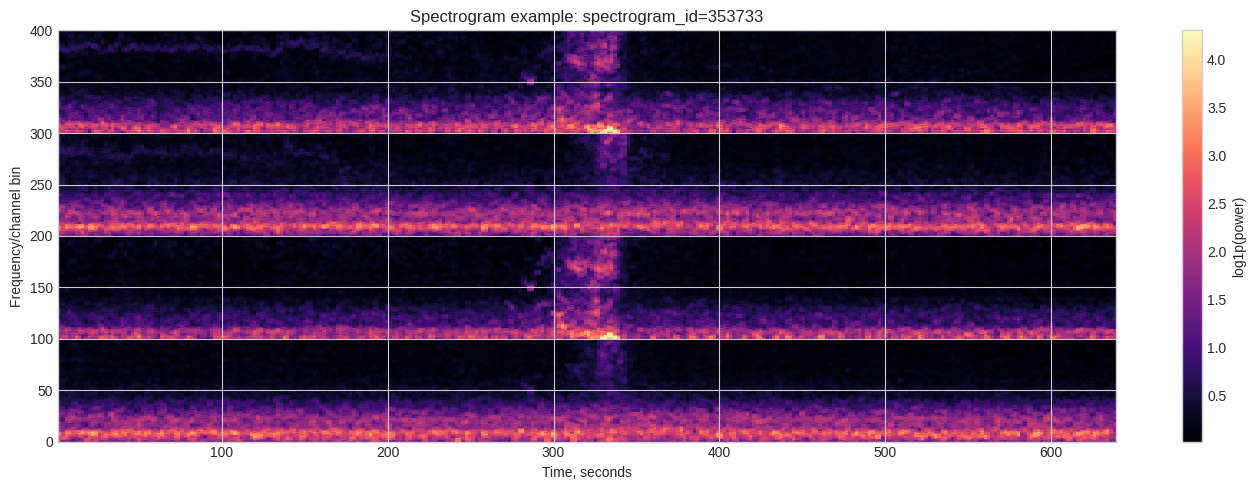

In [10]:
spectrogram_values = spectrogram.drop(columns=["time"], errors="ignore")
spectrogram_values = spectrogram_values.replace([np.inf, -np.inf], np.nan).fillna(0)

if "time" in spectrogram.columns:
    x_min = float(spectrogram["time"].min())
    x_max = float(spectrogram["time"].max())
else:
    x_min = 0.0
    x_max = float(len(spectrogram) - 1)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    np.log1p(spectrogram_values.values.T),
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="magma",
    extent=[x_min, x_max, 0, spectrogram_values.shape[1]],
)
ax.set_title(f"Spectrogram example: spectrogram_id={example_spectrogram_id}")
ax.set_xlabel("Time, seconds")
ax.set_ylabel("Frequency/channel bin")
fig.colorbar(im, ax=ax, label="log1p(power)")
plt.tight_layout()
plt.show()


Votes To Probabilities

In [11]:
train = train.copy()

train["vote_sum"] = train[LABEL_COLS].sum(axis=1)
train["max_vote"] = train[LABEL_COLS].max(axis=1)
train["agreement"] = train["max_vote"] / train["vote_sum"]

target_probs = train[LABEL_COLS].div(train["vote_sum"], axis=0)

target_cols = [f"target_{class_name}" for class_name in CLASS_NAMES]
target_probs.columns = target_cols

display(train[["expert_consensus", "vote_sum", "agreement"] + LABEL_COLS].head())
display(target_probs.head())

,expert_consensus,vote_sum,agreement,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,Seizure,3,1.0,3,0,0,0,0,0
1,Seizure,3,1.0,3,0,0,0,0,0
2,Seizure,3,1.0,3,0,0,0,0,0
3,Seizure,3,1.0,3,0,0,0,0,0
4,Seizure,3,1.0,3,0,0,0,0,0


,target_seizure,target_lpd,target_gpd,target_lrda,target_grda,target_other
0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0


In [12]:
ambiguous_idx = train.sort_values("agreement", ascending=True).index[0]

ambiguous_votes = train.loc[ambiguous_idx, LABEL_COLS]
ambiguous_target = target_probs.loc[ambiguous_idx]

ambiguous_table = pd.DataFrame(
    {
        "votes": ambiguous_votes.values,
        "target_probability": ambiguous_target.values,
    },
    index=CLASS_NAMES,
)

print("Most ambiguous example")
print("Expert consensus:", train.loc[ambiguous_idx, "expert_consensus"])
print("Agreement:", round(train.loc[ambiguous_idx, "agreement"], 3))
display(ambiguous_table)

Most ambiguous example
Expert consensus: Seizure
Agreement: 0.2


,votes,target_probability
seizure,1,0.2
lpd,1,0.2
gpd,0,0.0
lrda,1,0.2
grda,1,0.2
other,1,0.2


In [13]:
consensus_counts = (
    train["expert_consensus"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="rows")
)
consensus_counts["share"] = consensus_counts["rows"] / len(train)

vote_counts = train[LABEL_COLS].sum().rename_axis("class").reset_index(name="votes")
vote_counts["class"] = vote_counts["class"].str.replace("_vote", "", regex=False)
vote_counts["share"] = vote_counts["votes"] / vote_counts["votes"].sum()
vote_counts = vote_counts.sort_values("votes", ascending=False)

display(consensus_counts)
display(vote_counts)

,class,rows,share
0,Seizure,20933,0.196002
1,GRDA,18861,0.176601
2,Other,18808,0.176105
3,GPD,16702,0.156386
4,LRDA,16640,0.155805
5,LPD,14856,0.139101


,class,votes,share
5,other,209999,0.271006
2,gpd,135094,0.174340
1,lpd,121622,0.156954
4,grda,113121,0.145984
3,lrda,101278,0.130700
0,seizure,93773,0.121015


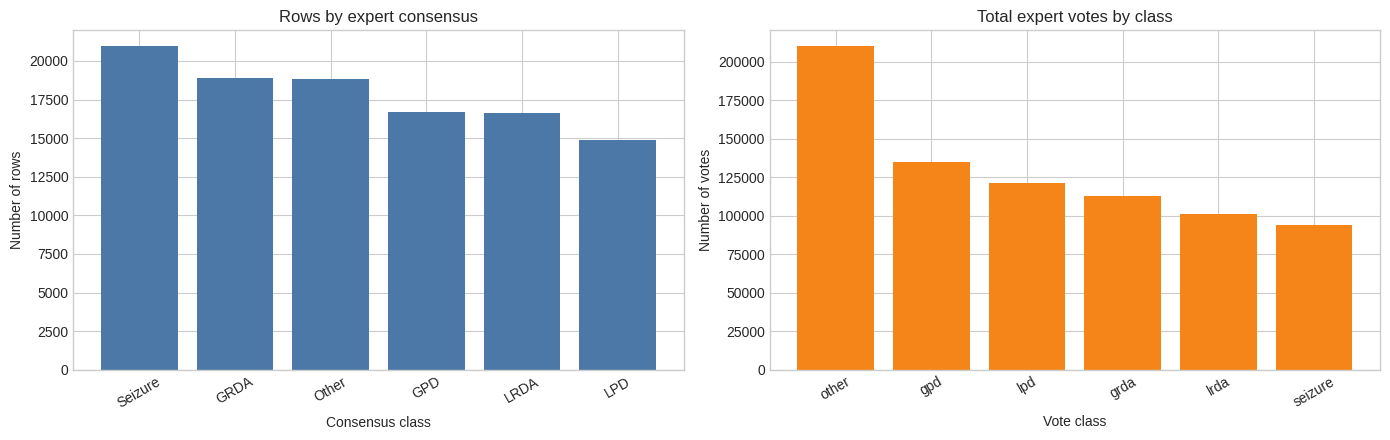

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(consensus_counts["class"], consensus_counts["rows"], color="#4C78A8")
axes[0].set_title("Rows by expert consensus")
axes[0].set_xlabel("Consensus class")
axes[0].set_ylabel("Number of rows")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(vote_counts["class"], vote_counts["votes"], color="#F58518")
axes[1].set_title("Total expert votes by class")
axes[1].set_xlabel("Vote class")
axes[1].set_ylabel("Number of votes")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Expert Agreement

`agreement = max_vote / vote_sum`.

- `1.0` means all experts voted for the same class.
- Lower values mean the sample is more ambiguous.

In [15]:
agreement_summary = train["agreement"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame()

agreement_bins = pd.cut(
    train["agreement"],
    bins=[0.0, 0.5, 0.7, 0.9, 1.0],
    labels=["<=0.50", "0.50-0.70", "0.70-0.90", "0.90-1.00"],
    include_lowest=True,
)
agreement_counts = agreement_bins.value_counts().sort_index().rename_axis("agreement_range").reset_index(name="rows")
agreement_counts["share"] = agreement_counts["rows"] / len(train)

display(agreement_summary)
display(agreement_counts)

,agreement
count,106800.000000
mean,0.816009
std,0.208296
min,0.200000
10%,0.500000
25%,0.666667
50%,0.928571
75%,1.000000
90%,1.000000
max,1.000000


,agreement_range,rows,share
0,<=0.50,12917,0.120946
1,0.50-0.70,26447,0.247631
2,0.70-0.90,12459,0.116657
3,0.90-1.00,54977,0.514766


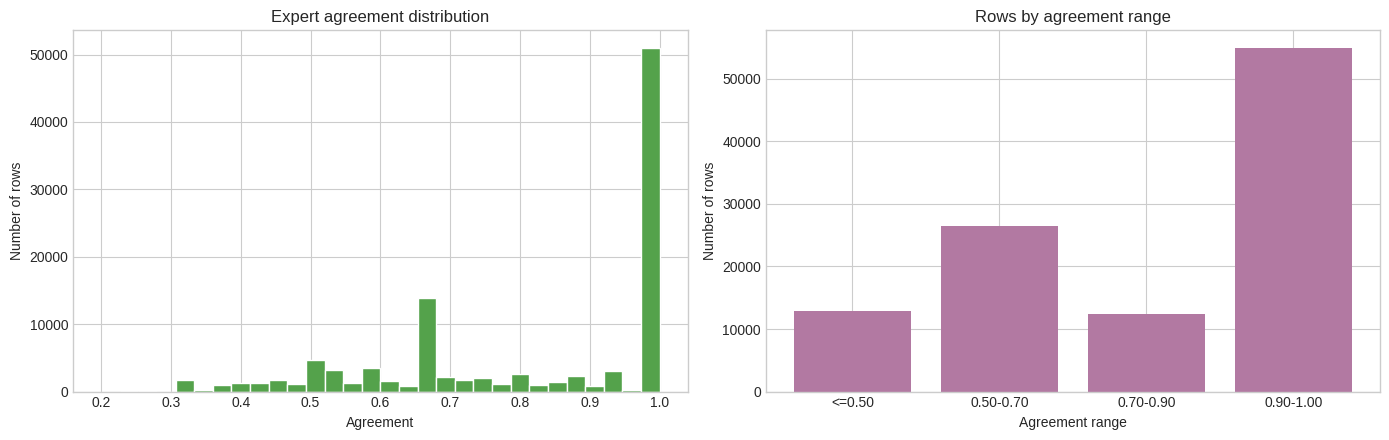

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(train["agreement"], bins=30, color="#54A24B", edgecolor="white")
axes[0].set_title("Expert agreement distribution")
axes[0].set_xlabel("Agreement")
axes[0].set_ylabel("Number of rows")

axes[1].bar(agreement_counts["agreement_range"].astype(str), agreement_counts["rows"], color="#B279A2")
axes[1].set_title("Rows by agreement range")
axes[1].set_xlabel("Agreement range")
axes[1].set_ylabel("Number of rows")

plt.tight_layout()
plt.show()

### Vote Count Distribution


In [17]:
vote_sum_counts = (
    train["vote_sum"]
    .value_counts()
    .sort_index()
    .rename_axis("vote_sum")
    .reset_index(name="rows")
)
vote_sum_counts["share"] = vote_sum_counts["rows"] / len(train)

expert_like_rows = int((train["vote_sum"] >= 10).sum())
low_vote_rows = int((train["vote_sum"] < 10).sum())

display(vote_sum_counts)
display(
    pd.DataFrame(
        {
            "group": ["vote_sum < 10", "vote_sum >= 10"],
            "rows": [low_vote_rows, expert_like_rows],
            "share": [low_vote_rows / len(train), expert_like_rows / len(train)],
        }
    )
)


,vote_sum,rows,share
0,1,4360,0.040824
1,2,2316,0.021685
2,3,51867,0.485646
3,4,3451,0.032313
4,5,3974,0.037210
5,6,883,0.008268
6,7,3,0.000028
7,10,1146,0.010730
8,11,2602,0.024363
9,12,4356,0.040787


,group,rows,share
0,vote_sum < 10,66854,0.625974
1,vote_sum >= 10,39946,0.374026


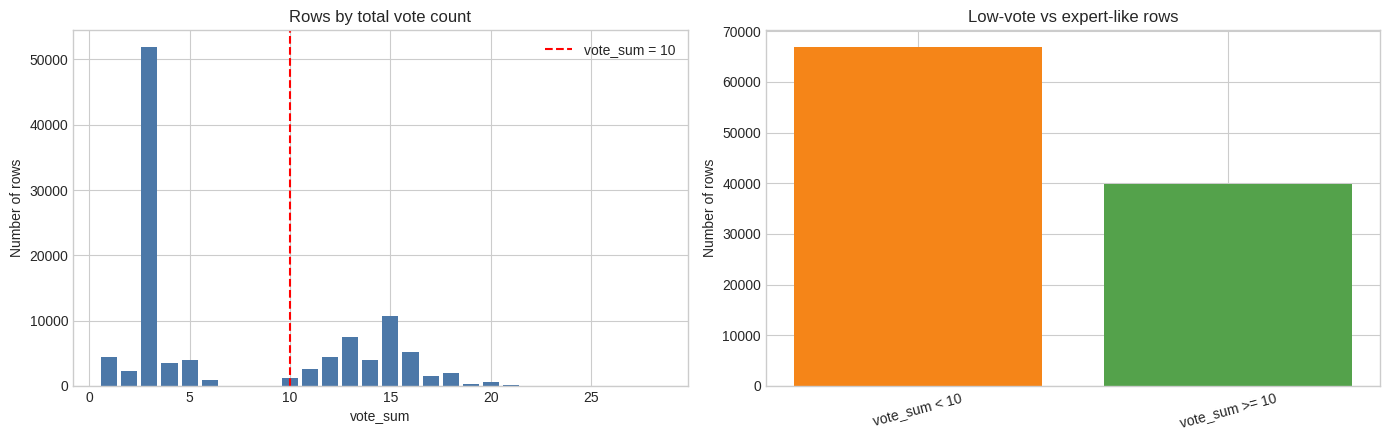

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(vote_sum_counts["vote_sum"], vote_sum_counts["rows"], color="#4C78A8")
axes[0].axvline(10, color="red", linestyle="--", label="vote_sum = 10")
axes[0].set_title("Rows by total vote count")
axes[0].set_xlabel("vote_sum")
axes[0].set_ylabel("Number of rows")
axes[0].legend()

group_counts = pd.Series(
    {
        "vote_sum < 10": low_vote_rows,
        "vote_sum >= 10": expert_like_rows,
    }
)
axes[1].bar(group_counts.index, group_counts.values, color=["#F58518", "#54A24B"])
axes[1].set_title("Low-vote vs expert-like rows")
axes[1].set_ylabel("Number of rows")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


## Validation Strategy


- `group = patient_id`: the same patient cannot appear in both train and validation for one fold;
- `stratify = expert_consensus`: each fold should have a similar class distribution;
- `n_splits = 5`: create five folds for cross-validation.

In [19]:
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 5

splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)

train["fold"] = -1

for fold, (_, valid_idx) in enumerate(
    splitter.split(
        train,
        y=train["expert_consensus"],
        groups=train["patient_id"],
    )
):
    train.loc[valid_idx, "fold"] = fold

display(train["fold"].value_counts().sort_index().to_frame("rows"))

,rows
fold,
0,21418
1,25231
2,22366
3,20739
4,17046


In [20]:
fold_class_balance = pd.crosstab(
    train["fold"],
    train["expert_consensus"],
    normalize="index",
)

display(fold_class_balance.style.format("{:.3f}"))

expert_consensus,GPD,GRDA,LPD,LRDA,Other,Seizure
fold,,,,,,
0,0.164,0.124,0.136,0.220,0.178,0.177
1,0.178,0.229,0.111,0.149,0.161,0.172
2,0.156,0.161,0.180,0.115,0.180,0.209
3,0.131,0.174,0.151,0.162,0.190,0.191
4,0.146,0.188,0.117,0.132,0.174,0.244


In [21]:
leakage_checks = []

for fold in range(N_SPLITS):
    valid_patients = set(train.loc[train["fold"] == fold, "patient_id"])
    train_patients = set(train.loc[train["fold"] != fold, "patient_id"])
    overlap = valid_patients & train_patients

    leakage_checks.append(
        {
            "fold": fold,
            "train_patients": len(train_patients),
            "valid_patients": len(valid_patients),
            "patient_overlap": len(overlap),
        }
    )

leakage_checks = pd.DataFrame(leakage_checks)
display(leakage_checks)

,fold,train_patients,valid_patients,patient_overlap
0,0,1559,391,0
1,1,1557,393,0
2,2,1563,387,0
3,3,1560,390,0
4,4,1561,389,0


## Official Kaggle Metric: KL Divergence


In [22]:
from typing import Optional


class ParticipantVisibleError(Exception):
    pass


def verify_valid_probabilities(df: pd.DataFrame, name: str, tolerance: float = 1e-6) -> None:
    values = df.to_numpy(dtype=float)

    if np.isnan(values).any():
        raise ParticipantVisibleError(f"{name} contains NaN values")
    if np.isinf(values).any():
        raise ParticipantVisibleError(f"{name} contains infinite values")
    if (values < -tolerance).any():
        raise ParticipantVisibleError(f"{name} contains negative probabilities")

    row_sums = values.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=tolerance):
        raise ParticipantVisibleError(f"{name} rows must sum to 1")


def kl_divergence(
    solution: pd.DataFrame,
    submission: pd.DataFrame,
    epsilon: float = 1e-15,
    micro_average: bool = True,
    sample_weights: Optional[pd.Series] = None,
) -> float:
    solution = solution.astype(float).copy()
    submission = submission.astype(float).copy()

    submission = submission.clip(epsilon, 1 - epsilon)

    loss = np.zeros_like(solution.to_numpy(dtype=float))
    y_true = solution.to_numpy(dtype=float)
    y_pred = submission.to_numpy(dtype=float)

    nonzero = y_true != 0
    loss[nonzero] = y_true[nonzero] * np.log(y_true[nonzero] / y_pred[nonzero])

    if micro_average:
        return float(np.average(loss.sum(axis=1), weights=sample_weights))
    return float(loss.mean())


def score(
    solution: pd.DataFrame,
    submission: pd.DataFrame,
    row_id_column_name: str,
    epsilon: float = 1e-15,
    micro_average: bool = True,
    sample_weights_column_name: Optional[str] = None,
) -> float:
    solution = solution.copy()
    submission = submission.copy()

    if row_id_column_name not in solution.columns:
        raise ParticipantVisibleError(f"{row_id_column_name} not found in solution columns")
    if row_id_column_name not in submission.columns:
        raise ParticipantVisibleError(f"{row_id_column_name} not found in submission columns")

    del solution[row_id_column_name]
    del submission[row_id_column_name]

    sample_weights = None
    if sample_weights_column_name:
        if sample_weights_column_name not in solution.columns:
            raise ParticipantVisibleError(f"{sample_weights_column_name} not found in solution columns")
        sample_weights = solution.pop(sample_weights_column_name)

    if sample_weights_column_name and not micro_average:
        raise ParticipantVisibleError("Sample weights are only valid if micro_average is True")

    for col in solution.columns:
        if col not in submission.columns:
            raise ParticipantVisibleError(f"Missing submission column {col}")

    submission = submission[solution.columns]

    verify_valid_probabilities(solution, "solution")
    verify_valid_probabilities(submission, "submission")

    return kl_divergence(
        solution=solution,
        submission=submission,
        epsilon=epsilon,
        micro_average=micro_average,
        sample_weights=sample_weights,
    )


## Spectrogram Preprocessing For Baseline

For the first baseline we will use precomputed spectrograms as model inputs.

Important: one `spectrogram_id` can appear in multiple rows with different `spectrogram_label_offset_seconds`


In [24]:
from collections import OrderedDict

TARGET_TIME_STEPS = 320
CACHE_SPECTROGRAMS = True
MAX_CACHE_ITEMS = 12_000  # enough to cache almost all train spectrogram files
SPECTROGRAM_CACHE = OrderedDict()

TIME_MASK_PROB = 0.5
TIME_MASK_MAX_WIDTH = 24
FEATURE_MASK_PROB = 0.5
FEATURE_MASK_MAX_WIDTH = 32


def crop_or_pad_time(image, target_time_steps=TARGET_TIME_STEPS):
    current_time_steps = image.shape[0]

    if current_time_steps == target_time_steps:
        return image

    if current_time_steps > target_time_steps:
        return image[:target_time_steps]

    pad_after = target_time_steps - current_time_steps
    return np.pad(image, ((0, pad_after), (0, 0)), mode="constant", constant_values=0)


def load_spectrogram_array(spectrogram_id):
    spectrogram_id = int(spectrogram_id)

    if CACHE_SPECTROGRAMS and spectrogram_id in SPECTROGRAM_CACHE:
        SPECTROGRAM_CACHE.move_to_end(spectrogram_id)
        return SPECTROGRAM_CACHE[spectrogram_id]

    path = DATA_DIR / "train_spectrograms" / f"{spectrogram_id}.parquet"
    spectrogram_df = pd.read_parquet(path)

    if "time" in spectrogram_df.columns:
        time_values = spectrogram_df["time"].to_numpy(dtype=np.float32)
    else:
        time_values = None

    values = spectrogram_df.drop(columns=["time"], errors="ignore")
    values = values.replace([np.inf, -np.inf], np.nan).fillna(0)
    image = np.log1p(values.to_numpy(dtype=np.float32))

    item = (image, time_values)

    if CACHE_SPECTROGRAMS:
        SPECTROGRAM_CACHE[spectrogram_id] = item
        SPECTROGRAM_CACHE.move_to_end(spectrogram_id)
        while len(SPECTROGRAM_CACHE) > MAX_CACHE_ITEMS:
            SPECTROGRAM_CACHE.popitem(last=False)

    return item


def read_spectrogram_image(spectrogram_id, offset_seconds):
    image, time_values = load_spectrogram_array(spectrogram_id)

    if time_values is not None:
        start_idx = int(np.searchsorted(time_values, float(offset_seconds), side="left"))
    else:
        start_idx = 0

    segment = image[start_idx:start_idx + TARGET_TIME_STEPS].copy()
    segment = crop_or_pad_time(segment)
    segment = (segment - segment.mean()) / (segment.std() + 1e-6)

    return segment.astype(np.float32)


def make_target(row):
    votes = row[LABEL_COLS].to_numpy(dtype=np.float32)
    return votes / votes.sum()


## PyTorch Dataset And DataLoader


In [25]:
import torch
from torch.utils.data import DataLoader, Dataset


In [ ]:
class HmsSpectrogramDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def apply_spec_augment(self, image):
        if not self.augment:
            return image

        # image shape: [time, features]
        time_steps, n_features = image.shape

        if np.random.rand() < TIME_MASK_PROB:
            width = np.random.randint(1, TIME_MASK_MAX_WIDTH + 1)
            start = np.random.randint(0, max(1, time_steps - width + 1))
            image[start:start + width, :] = 0

        if np.random.rand() < FEATURE_MASK_PROB:
            width = np.random.randint(1, FEATURE_MASK_MAX_WIDTH + 1)
            start = np.random.randint(0, max(1, n_features - width + 1))
            image[:, start:start + width] = 0

        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = read_spectrogram_image(
            spectrogram_id=row["spectrogram_id"],
            offset_seconds=row["spectrogram_label_offset_seconds"],
        )
        image = self.apply_spec_augment(image.copy())
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)

        target = make_target(row)
        target = torch.tensor(target, dtype=torch.float32)

        return image, target


In [27]:
train_df = train[train["fold"] != 0].reset_index(drop=True)
valid_df = train[train["fold"] == 0].reset_index(drop=True)

debug_train_df = train_df.head(64).copy()
debug_valid_df = valid_df.head(32).copy()

train_dataset = HmsSpectrogramDataset(debug_train_df, augment=True)
valid_dataset = HmsSpectrogramDataset(debug_valid_df, augment=False)

print("train dataset size:", len(train_dataset))
print("valid dataset size:", len(valid_dataset))


train dataset size: 64
valid dataset size: 32


In [28]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

images, targets = next(iter(train_loader))

print("images shape:", images.shape)
print("targets shape:", targets.shape)
print("target row sums:", targets.sum(dim=1))


images shape: torch.Size([8, 1, 320, 400])
targets shape: torch.Size([8, 6])
target row sums: tensor([1., 1., 1., 1., 1., 1., 1., 1.])




```text
images:  [batch_size, 1, time, features]
targets: [batch_size, 6]
```


In [29]:
import os

USE_WANDB = True
WANDB_PROJECT = "hms-hbac-assignment"
WANDB_RUN_NAME = "efficientnet-b0-spectrogram-fold0"

try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    wandb = None
    WANDB_AVAILABLE = False
    USE_WANDB = False
    print("wandb is not installed. Training will continue without W&B logging.")


In [30]:
def setup_wandb_login():
    if not USE_WANDB or not WANDB_AVAILABLE:
        return False

    api_key = os.environ.get("WANDB_API_KEY")

    if api_key is None:
        try:
            from kaggle_secrets import UserSecretsClient
            api_key = UserSecretsClient().get_secret("WANDB_API_KEY")
        except Exception:
            api_key = None

    try:
        if api_key:
            wandb.login(key=api_key)
            print("W&B login successful using API key.")
        else:
            wandb.login(anonymous="allow")
            print("W&B login using anonymous mode. Add WANDB_API_KEY for your own account.")
        return True
    except Exception as error:
        print(f"W&B login failed: {error}")
        return False


WANDB_ENABLED = setup_wandb_login()
print("W&B enabled:", WANDB_ENABLED)


wandb: WARNING The anonymous parameter to wandb.login() has no effect and will be removed in future versions.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tkharin (tkharin-kyiv-school-of-economics) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login using anonymous mode. Add WANDB_API_KEY for your own account.
W&B enabled: True


In [31]:
experiment_config = {
    "model": "efficientnet_b0",
    "input": "precomputed_spectrograms",
    "target_time_steps": TARGET_TIME_STEPS,
    "n_classes": len(CLASS_NAMES),
    "validation": "StratifiedGroupKFold",
    "group_column": "patient_id",
    "valid_fold": 0,
    "metric": "KL divergence",
    "seed": SEED,
    "cache_spectrograms": CACHE_SPECTROGRAMS,
    "max_cache_items": MAX_CACHE_ITEMS,
}

display(pd.Series(experiment_config, name="value").to_frame())


,value
model,efficientnet_b0
input,precomputed_spectrograms
target_time_steps,320
n_classes,6
validation,StratifiedGroupKFold
group_column,patient_id
valid_fold,0
metric,KL divergence
seed,1488
cache_spectrograms,True


## EfficientNet-B0 Baseline


In [32]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
from tqdm.auto import tqdm


device: cuda


In [40]:
MODEL_NAME = "efficientnet_b0"
IMAGE_SIZE = 224
TRAIN_LIMIT = None
VALID_LIMIT = None
EPOCHS = 5
# TRAIN_LIMIT = 4096
# VALID_LIMIT = 1024
# EPOCHS = 2
BATCH_SIZE = 16
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4
DROPOUT = 0.3
USE_AMP = torch.cuda.is_available()
NUM_WORKERS = 0

In [ ]:
train_run_df = train_df.sample(n=min(TRAIN_LIMIT, len(train_df)), random_state=SEED).reset_index(drop=True) if TRAIN_LIMIT else train_df
valid_run_df = valid_df.sample(n=min(VALID_LIMIT, len(valid_df)), random_state=SEED).reset_index(drop=True) if VALID_LIMIT else valid_df

train_run_dataset = HmsSpectrogramDataset(train_run_df, augment=True)
valid_run_dataset = HmsSpectrogramDataset(valid_run_df, augment=False)

train_run_loader = DataLoader(
    train_run_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

valid_run_loader = DataLoader(
    valid_run_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("train samples:", len(train_run_dataset))
print("valid samples:", len(valid_run_dataset))


train samples: 85382
valid samples: 21418


In [38]:
def create_model():
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=DROPOUT),
        nn.Linear(in_features, len(CLASS_NAMES)),
    )
    return model

In [ ]:
model = create_model().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)


In [49]:
def prepare_images(images):
    images = images.to(DEVICE, non_blocking=True)
    images = images.repeat(1, 3, 1, 1)
    images = F.interpolate(images, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
    return images


def soft_cross_entropy_loss(logits, targets):
    log_probs = F.log_softmax(logits, dim=1)
    return -(targets * log_probs).sum(dim=1).mean()


def kl_score_from_arrays(y_true, y_pred, epsilon=1e-15):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = np.zeros_like(y_true)
    nonzero = y_true != 0
    loss[nonzero] = y_true[nonzero] * np.log(y_true[nonzero] / y_pred[nonzero])
    return float(loss.sum(axis=1).mean())


In [47]:
def train_one_epoch(model, loader, optimizer, scaler, epoch):
    model.train()
    losses = []

    progress = tqdm(loader, desc=f"Epoch {epoch} train", leave=False)
    for images, targets in progress:
        images = prepare_images(images)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = soft_cross_entropy_loss(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)
        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

    return float(np.mean(losses))


@torch.no_grad()
def validate(model, loader, epoch):
    model.eval()
    losses = []
    all_targets = []
    all_probs = []

    progress = tqdm(loader, desc=f"Epoch {epoch} valid", leave=False)
    for images, targets in progress:
        images = prepare_images(images)
        targets = targets.to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = soft_cross_entropy_loss(logits, targets)
        probs = torch.softmax(logits.float(), dim=1)

        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)
        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

        all_targets.append(targets.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(all_targets, axis=0)
    y_pred = np.concatenate(all_probs, axis=0)
    kl = kl_score_from_arrays(y_true, y_pred)

    return float(np.mean(losses)), kl


In [ ]:
run = None
if WANDB_ENABLED:
    run_config = dict(experiment_config)
    run_config.update(
        {
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "dropout": DROPOUT,
            "image_size": IMAGE_SIZE,
            "train_limit": TRAIN_LIMIT,
            "valid_limit": VALID_LIMIT,
            "time_mask_prob": TIME_MASK_PROB,
            "time_mask_max_width": TIME_MASK_MAX_WIDTH,
            "feature_mask_prob": FEATURE_MASK_PROB,
            "feature_mask_max_width": FEATURE_MASK_MAX_WIDTH,
            "use_amp": USE_AMP,
        }
    )
    run = wandb.init(project=WANDB_PROJECT, name=WANDB_RUN_NAME, config=run_config)

history = []
best_valid_kl = float("inf")
best_epoch = None
best_checkpoint_path = "best_efficientnet_b0_fold0.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_run_loader, optimizer, scaler, epoch)
    valid_loss, valid_kl = validate(model, valid_run_loader, epoch)
    scheduler.step()

    if valid_kl < best_valid_kl:
        best_valid_kl = valid_kl
        best_epoch = epoch
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "valid_kl": best_valid_kl,
                "epoch": best_epoch,
                "class_names": CLASS_NAMES,
            },
            best_checkpoint_path,
        )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_kl": valid_kl,
        "best_valid_kl": best_valid_kl,
        "best_epoch": best_epoch,
        "lr": scheduler.get_last_lr()[0],
    }
    history.append(row)

    print(row)

    if WANDB_ENABLED:
        wandb.log(row)

if WANDB_ENABLED:
    wandb.finish()

history_df = pd.DataFrame(history)
display(history_df)
print("Best checkpoint:", best_checkpoint_path)


Epoch 1 train:   0%|          | 0/5337 [00:00<?, ?it/s]

Epoch 1 valid:   0%|          | 0/1339 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.0045869496792517, 'valid_loss': 1.1156990740937198, 'valid_kl': 0.7517063978970717, 'best_valid_kl': 0.7517063978970717, 'best_epoch': 1, 'lr': 4.522542485937369e-05}


Epoch 2 train:   0%|          | 0/5337 [00:00<?, ?it/s]

Epoch 2 valid:   0%|          | 0/1339 [00:00<?, ?it/s]

...

Epoch 5 valid:   0%|          | 0/1339 [00:00<?, ?it/s]

{'epoch': 5, 'train_loss': 0.6214473525979042, 'valid_loss': 1.269863073115047, 'valid_kl': 0.9058962284365241, 'best_valid_kl': 0.7517063978970717, 'best_epoch': 1, 'lr': 0.0}


best_epoch,▁▁▁▁▁
best_valid_kl,▁▁▁▁▁
epoch,▁▃▅▆█
lr,█▆▄▂▁
train_loss,█▄▂▁▁
valid_kl,▁▆▅█▇
valid_loss,▁▆▅█▇
best_epoch,1
best_valid_kl,0.75171
epoch,5
lr,0


,epoch,train_loss,valid_loss,valid_kl,best_valid_kl,best_epoch,lr
0,1,1.004587,1.115699,0.751706,0.751706,1,0.000045
1,2,0.771633,1.230063,0.866107,0.751706,1,0.000033
2,3,0.687833,1.202836,0.838865,0.751706,1,0.000017
3,4,0.643386,1.283671,0.919702,0.751706,1,0.000005
4,5,0.621447,1.269863,0.905896,0.751706,1,0.000000


Best checkpoint: best_efficientnet_b0_fold0.pt


## Freeze/Unfreeze EfficientNet-B0 


In [45]:
FREEZE_EPOCHS = 1
UNFREEZE_EPOCHS = 3
HEAD_LR = 1e-4
BACKBONE_LR = 1e-5
FREEZE_EXPERIMENT_CHECKPOINT = "best_efficientnet_b0_freeze_unfreeze_fold0.pt"


In [43]:
def set_backbone_trainable(model, trainable):
    for parameter in model.features.parameters():
        parameter.requires_grad = trainable


def create_optimizer_for_current_stage(model, lr):
    trainable_parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
    return torch.optim.AdamW(trainable_parameters, lr=lr, weight_decay=WEIGHT_DECAY)


In [ ]:
freeze_model = create_model().to(DEVICE)
freeze_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

freeze_history = []
freeze_best_valid_kl = float("inf")
freeze_best_epoch = None


### Stage 1: Train Classifier Head Only


In [ ]:
set_backbone_trainable(freeze_model, trainable=False)
freeze_optimizer = create_optimizer_for_current_stage(freeze_model, lr=HEAD_LR)

for epoch in range(1, FREEZE_EPOCHS + 1):
    train_loss = train_one_epoch(freeze_model, train_run_loader, freeze_optimizer, freeze_scaler, epoch)
    valid_loss, valid_kl = validate(freeze_model, valid_run_loader, epoch)

    if valid_kl < freeze_best_valid_kl:
        freeze_best_valid_kl = valid_kl
        freeze_best_epoch = epoch
        torch.save(
            {
                "model_state_dict": freeze_model.state_dict(),
                "valid_kl": freeze_best_valid_kl,
                "epoch": freeze_best_epoch,
                "stage": "frozen_backbone",
                "class_names": CLASS_NAMES,
            },
            FREEZE_EXPERIMENT_CHECKPOINT,
        )

    row = {
        "stage": "frozen_backbone",
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_kl": valid_kl,
        "best_valid_kl": freeze_best_valid_kl,
        "best_epoch": freeze_best_epoch,
        "lr": HEAD_LR,
    }
    freeze_history.append(row)
    print(row)


Epoch 1 train:   0%|          | 0/5337 [00:00<?, ?it/s]

Epoch 1 valid:   0%|          | 0/1339 [00:00<?, ?it/s]

{'stage': 'frozen_backbone', 'epoch': 1, 'train_loss': 1.4571954689938096, 'valid_loss': 1.3952195676540242, 'valid_kl': 1.0311233983452506, 'best_valid_kl': 1.0311233983452506, 'best_epoch': 1, 'lr': 0.0001}


### Stage 2: Fine-Tune Full Model With Small LR


In [ ]:
set_backbone_trainable(freeze_model, trainable=True)
freeze_optimizer = create_optimizer_for_current_stage(freeze_model, lr=BACKBONE_LR)
freeze_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(freeze_optimizer, T_max=UNFREEZE_EPOCHS)

for stage_epoch in range(1, UNFREEZE_EPOCHS + 1):
    epoch = FREEZE_EPOCHS + stage_epoch
    train_loss = train_one_epoch(freeze_model, train_run_loader, freeze_optimizer, freeze_scaler, epoch)
    valid_loss, valid_kl = validate(freeze_model, valid_run_loader, epoch)
    freeze_scheduler.step()

    if valid_kl < freeze_best_valid_kl:
        freeze_best_valid_kl = valid_kl
        freeze_best_epoch = epoch
        torch.save(
            {
                "model_state_dict": freeze_model.state_dict(),
                "valid_kl": freeze_best_valid_kl,
                "epoch": freeze_best_epoch,
                "stage": "full_finetune",
                "class_names": CLASS_NAMES,
            },
            FREEZE_EXPERIMENT_CHECKPOINT,
        )

    row = {
        "stage": "full_finetune",
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_kl": valid_kl,
        "best_valid_kl": freeze_best_valid_kl,
        "best_epoch": freeze_best_epoch,
        "lr": freeze_scheduler.get_last_lr()[0],
    }
    freeze_history.append(row)
    print(row)


Epoch 2 train:   0%|          | 0/5337 [00:00<?, ?it/s]

Epoch 2 valid:   0%|          | 0/1339 [00:00<?, ?it/s]

{'stage': 'full_finetune', 'epoch': 2, 'train_loss': 1.1819305823316997, 'valid_loss': 1.1754526959424747, 'valid_kl': 0.8114049204754932, 'best_valid_kl': 0.8114049204754932, 'best_epoch': 2, 'lr': 7.500000000000001e-06}


Epoch 3 train:   0%|          | 0/5337 [00:00<?, ?it/s]

Epoch 3 valid:   0%|          | 0/1339 [00:00<?, ?it/s]

{'stage': 'full_finetune', 'epoch': 3, 'train_loss': 1.0115476304981756, 'valid_loss': 1.1362317618764408, 'valid_kl': 0.772191153042521, 'best_valid_kl': 0.772191153042521, 'best_epoch': 3, 'lr': 2.5000000000000015e-06}


Epoch 4 train:   0%|          | 0/5337 [00:00<?, ?it/s]

Epoch 4 valid:   0%|          | 0/1339 [00:00<?, ?it/s]

{'stage': 'full_finetune', 'epoch': 4, 'train_loss': 0.9531236006477832, 'valid_loss': 1.1055847845673894, 'valid_kl': 0.7415437926823146, 'best_valid_kl': 0.7415437926823146, 'best_epoch': 4, 'lr': 0.0}


In [ ]:
freeze_history_df = pd.DataFrame(freeze_history)
display(freeze_history_df)
print("Best freeze/unfreeze KL:", freeze_best_valid_kl)
print("Best freeze/unfreeze epoch:", freeze_best_epoch)
print("Checkpoint:", FREEZE_EXPERIMENT_CHECKPOINT)


## Expert-Like Vote Count Experiment


In [33]:
EXPERT_VOTE_THRESHOLD = 10

expert_train = train[train["vote_sum"] >= EXPERT_VOTE_THRESHOLD].copy().reset_index(drop=True)

print("all train rows:", len(train))
print("expert-like rows:", len(expert_train))
print("expert-like share:", round(len(expert_train) / len(train), 4))


all train rows: 106800
expert-like rows: 39946
expert-like share: 0.374


In [34]:
expert_splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)

expert_train["fold"] = -1

for fold, (_, valid_idx) in enumerate(
    expert_splitter.split(
        expert_train,
        y=expert_train["expert_consensus"],
        groups=expert_train["patient_id"],
    )
):
    expert_train.loc[valid_idx, "fold"] = fold

display(expert_train["fold"].value_counts().sort_index().to_frame("rows"))
display(pd.crosstab(expert_train["fold"], expert_train["expert_consensus"], normalize="index").style.format("{:.3f}"))


,rows
fold,
0,6318
1,8007
2,8896
3,9530
4,7195


expert_consensus,GPD,GRDA,LPD,LRDA,Other,Seizure
fold,,,,,,
0,0.176,0.077,0.203,0.201,0.321,0.021
1,0.285,0.129,0.166,0.151,0.259,0.010
2,0.239,0.229,0.156,0.122,0.243,0.011
3,0.392,0.113,0.140,0.152,0.187,0.015
4,0.114,0.104,0.292,0.168,0.302,0.020


In [36]:
expert_train_df = expert_train[expert_train["fold"] != 0].reset_index(drop=True)
expert_valid_df = expert_train[expert_train["fold"] == 0].reset_index(drop=True)

expert_train_dataset = HmsSpectrogramDataset(expert_train_df, augment=True)
expert_valid_dataset = HmsSpectrogramDataset(expert_valid_df, augment=False)

expert_train_loader = DataLoader(
    expert_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

expert_valid_loader = DataLoader(
    expert_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("expert train samples:", len(expert_train_dataset))
print("expert valid samples:", len(expert_valid_dataset))


expert train samples: 33628
expert valid samples: 6318


In [41]:
EXPERT_CHECKPOINT = "best_efficientnet_b0_expert_vote10_fold0.pt"

expert_model = create_model().to(DEVICE)
expert_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
expert_history = []
expert_best_valid_kl = float("inf")
expert_best_epoch = None


In [50]:
# Stage 1: frozen backbone
set_backbone_trainable(expert_model, trainable=False)
expert_optimizer = create_optimizer_for_current_stage(expert_model, lr=HEAD_LR)

for epoch in range(1, FREEZE_EPOCHS + 1):
    train_loss = train_one_epoch(expert_model, expert_train_loader, expert_optimizer, expert_scaler, epoch)
    valid_loss, valid_kl = validate(expert_model, expert_valid_loader, epoch)

    if valid_kl < expert_best_valid_kl:
        expert_best_valid_kl = valid_kl
        expert_best_epoch = epoch
        torch.save({"model_state_dict": expert_model.state_dict(), "valid_kl": expert_best_valid_kl, "epoch": expert_best_epoch, "class_names": CLASS_NAMES}, EXPERT_CHECKPOINT)

    row = {"stage": "expert_frozen", "epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss, "valid_kl": valid_kl, "best_valid_kl": expert_best_valid_kl, "best_epoch": expert_best_epoch, "lr": HEAD_LR}
    expert_history.append(row)
    print(row)


Epoch 1 train:   0%|          | 0/4204 [00:00<?, ?it/s]

Epoch 1 valid:   0%|          | 0/790 [00:00<?, ?it/s]

{'stage': 'expert_frozen', 'epoch': 1, 'train_loss': 1.4267036440852254, 'valid_loss': 1.4561053494863871, 'valid_kl': 0.7536904381113826, 'best_valid_kl': 0.7536904381113826, 'best_epoch': 1, 'lr': 0.0001}


In [51]:
# Stage 2: full fine-tune
set_backbone_trainable(expert_model, trainable=True)
expert_optimizer = create_optimizer_for_current_stage(expert_model, lr=BACKBONE_LR)
expert_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(expert_optimizer, T_max=UNFREEZE_EPOCHS)

for stage_epoch in range(1, UNFREEZE_EPOCHS + 1):
    epoch = FREEZE_EPOCHS + stage_epoch
    train_loss = train_one_epoch(expert_model, expert_train_loader, expert_optimizer, expert_scaler, epoch)
    valid_loss, valid_kl = validate(expert_model, expert_valid_loader, epoch)
    expert_scheduler.step()

    if valid_kl < expert_best_valid_kl:
        expert_best_valid_kl = valid_kl
        expert_best_epoch = epoch
        torch.save({"model_state_dict": expert_model.state_dict(), "valid_kl": expert_best_valid_kl, "epoch": expert_best_epoch, "class_names": CLASS_NAMES}, EXPERT_CHECKPOINT)

    row = {"stage": "expert_full_finetune", "epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss, "valid_kl": valid_kl, "best_valid_kl": expert_best_valid_kl, "best_epoch": expert_best_epoch, "lr": expert_scheduler.get_last_lr()[0]}
    expert_history.append(row)
    print(row)


Epoch 2 train:   0%|          | 0/4204 [00:00<?, ?it/s]

Epoch 2 valid:   0%|          | 0/790 [00:00<?, ?it/s]

{'stage': 'expert_full_finetune', 'epoch': 2, 'train_loss': 1.2405735867631424, 'valid_loss': 1.3242265187109572, 'valid_kl': 0.6217287968195844, 'best_valid_kl': 0.6217287968195844, 'best_epoch': 2, 'lr': 7.500000000000001e-06}


Epoch 3 train:   0%|          | 0/4204 [00:00<?, ?it/s]

Epoch 3 valid:   0%|          | 0/790 [00:00<?, ?it/s]

{'stage': 'expert_full_finetune', 'epoch': 3, 'train_loss': 1.1414676095110026, 'valid_loss': 1.26760307327856, 'valid_kl': 0.565116965448714, 'best_valid_kl': 0.565116965448714, 'best_epoch': 3, 'lr': 2.5000000000000015e-06}


Epoch 4 train:   0%|          | 0/4204 [00:00<?, ?it/s]

Epoch 4 valid:   0%|          | 0/790 [00:00<?, ?it/s]

{'stage': 'expert_full_finetune', 'epoch': 4, 'train_loss': 1.1011997444588837, 'valid_loss': 1.259120606168916, 'valid_kl': 0.5566085604395555, 'best_valid_kl': 0.5566085604395555, 'best_epoch': 4, 'lr': 0.0}


In [52]:
expert_history_df = pd.DataFrame(expert_history)
display(expert_history_df)
print("Best expert-like KL:", expert_best_valid_kl)
print("Best expert-like epoch:", expert_best_epoch)
print("Checkpoint:", EXPERT_CHECKPOINT)


,stage,epoch,train_loss,valid_loss,valid_kl,best_valid_kl,best_epoch,lr
0,expert_frozen,1,1.426704,1.456105,0.753690,0.753690,1,0.000100
1,expert_full_finetune,2,1.240574,1.324227,0.621729,0.621729,2,0.000008
2,expert_full_finetune,3,1.141468,1.267603,0.565117,0.565117,3,0.000003
3,expert_full_finetune,4,1.101200,1.259121,0.556609,0.556609,4,0.000000


Best expert-like KL: 0.5566085604395555
Best expert-like epoch: 4
Checkpoint: best_efficientnet_b0_expert_vote10_fold0.pt


## 4-Channel Spectrogram Experiment

The Kaggle spectrogram has columns grouped by brain-region prefixes: `LL`, `LP`, `RP`, and `RL`.

Instead of treating all 400 features as one wide image, we split them into four channels:

```text
channel 0 = LL_*
channel 1 = LP_*
channel 2 = RP_*
channel 3 = RL_*
```


In [53]:
SPECTROGRAM_PREFIXES = ["LL", "LP", "RP", "RL"]
FOUR_CHANNEL_CHECKPOINT = "best_efficientnet_b0_expert_vote10_4ch_fold0.pt"


In [54]:
def load_spectrogram_groups(spectrogram_id):
    spectrogram_id = int(spectrogram_id)
    cache_key = ("groups", spectrogram_id)

    if CACHE_SPECTROGRAMS and cache_key in SPECTROGRAM_CACHE:
        SPECTROGRAM_CACHE.move_to_end(cache_key)
        return SPECTROGRAM_CACHE[cache_key]

    path = DATA_DIR / "train_spectrograms" / f"{spectrogram_id}.parquet"
    spectrogram_df = pd.read_parquet(path)

    if "time" in spectrogram_df.columns:
        time_values = spectrogram_df["time"].to_numpy(dtype=np.float32)
    else:
        time_values = None

    channels = []
    for prefix in SPECTROGRAM_PREFIXES:
        cols = [col for col in spectrogram_df.columns if col.startswith(f"{prefix}_")]
        values = spectrogram_df[cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        channel = np.log1p(values.to_numpy(dtype=np.float32))
        channels.append(channel)

    item = (channels, time_values)

    if CACHE_SPECTROGRAMS:
        SPECTROGRAM_CACHE[cache_key] = item
        SPECTROGRAM_CACHE.move_to_end(cache_key)
        while len(SPECTROGRAM_CACHE) > MAX_CACHE_ITEMS:
            SPECTROGRAM_CACHE.popitem(last=False)

    return item


def read_four_channel_spectrogram(spectrogram_id, offset_seconds):
    channels, time_values = load_spectrogram_groups(spectrogram_id)

    if time_values is not None:
        start_idx = int(np.searchsorted(time_values, float(offset_seconds), side="left"))
    else:
        start_idx = 0

    processed_channels = []
    for channel in channels:
        segment = channel[start_idx:start_idx + TARGET_TIME_STEPS].copy()
        segment = crop_or_pad_time(segment)
        segment = (segment - segment.mean()) / (segment.std() + 1e-6)
        processed_channels.append(segment.astype(np.float32))

    image = np.stack(processed_channels, axis=0)
    return image


In [55]:
class HmsFourChannelSpectrogramDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def apply_spec_augment(self, image):
        if not self.augment:
            return image

        _, time_steps, n_features = image.shape

        if np.random.rand() < TIME_MASK_PROB:
            width = np.random.randint(1, TIME_MASK_MAX_WIDTH + 1)
            start = np.random.randint(0, max(1, time_steps - width + 1))
            image[:, start:start + width, :] = 0

        if np.random.rand() < FEATURE_MASK_PROB:
            width = np.random.randint(1, min(FEATURE_MASK_MAX_WIDTH, n_features) + 1)
            start = np.random.randint(0, max(1, n_features - width + 1))
            image[:, :, start:start + width] = 0

        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = read_four_channel_spectrogram(
            spectrogram_id=row["spectrogram_id"],
            offset_seconds=row["spectrogram_label_offset_seconds"],
        )
        image = self.apply_spec_augment(image.copy())
        image = torch.tensor(image, dtype=torch.float32)

        target = make_target(row)
        target = torch.tensor(target, dtype=torch.float32)

        return image, target


In [56]:
fourch_train_dataset = HmsFourChannelSpectrogramDataset(expert_train_df, augment=True)
fourch_valid_dataset = HmsFourChannelSpectrogramDataset(expert_valid_df, augment=False)

fourch_train_loader = DataLoader(
    fourch_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

fourch_valid_loader = DataLoader(
    fourch_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

images, targets = next(iter(fourch_train_loader))
print("images shape:", images.shape)
print("targets shape:", targets.shape)


images shape: torch.Size([16, 4, 320, 100])
targets shape: torch.Size([16, 6])


In [57]:
def create_four_channel_model():
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    old_conv = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=4,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    with torch.no_grad():
        new_conv.weight[:, :3] = old_conv.weight
        new_conv.weight[:, 3:4] = old_conv.weight.mean(dim=1, keepdim=True)
    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=DROPOUT),
        nn.Linear(in_features, len(CLASS_NAMES)),
    )
    return model


def prepare_four_channel_images(images):
    images = images.to(DEVICE, non_blocking=True)
    images = F.interpolate(images, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
    return images


In [58]:
def train_one_epoch_fourch(model, loader, optimizer, scaler, epoch):
    model.train()
    losses = []
    progress = tqdm(loader, desc=f"Epoch {epoch} train 4ch", leave=False)

    for images, targets in progress:
        images = prepare_four_channel_images(images)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = soft_cross_entropy_loss(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)
        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

    return float(np.mean(losses))


@torch.no_grad()
def validate_fourch(model, loader, epoch):
    model.eval()
    losses = []
    all_targets = []
    all_probs = []
    progress = tqdm(loader, desc=f"Epoch {epoch} valid 4ch", leave=False)

    for images, targets in progress:
        images = prepare_four_channel_images(images)
        targets = targets.to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = soft_cross_entropy_loss(logits, targets)
        probs = torch.softmax(logits.float(), dim=1)

        losses.append(float(loss.detach().cpu()))
        progress.set_postfix(loss=f"{np.mean(losses):.4f}")
        all_targets.append(targets.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(all_targets, axis=0)
    y_pred = np.concatenate(all_probs, axis=0)
    kl = kl_score_from_arrays(y_true, y_pred)
    return float(np.mean(losses)), kl


In [59]:
fourch_model = create_four_channel_model().to(DEVICE)
fourch_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
fourch_history = []
fourch_best_valid_kl = float("inf")
fourch_best_epoch = None


In [60]:
# Stage 1: frozen backbone
set_backbone_trainable(fourch_model, trainable=False)
fourch_optimizer = create_optimizer_for_current_stage(fourch_model, lr=HEAD_LR)

for epoch in range(1, FREEZE_EPOCHS + 1):
    train_loss = train_one_epoch_fourch(fourch_model, fourch_train_loader, fourch_optimizer, fourch_scaler, epoch)
    valid_loss, valid_kl = validate_fourch(fourch_model, fourch_valid_loader, epoch)

    if valid_kl < fourch_best_valid_kl:
        fourch_best_valid_kl = valid_kl
        fourch_best_epoch = epoch
        torch.save({"model_state_dict": fourch_model.state_dict(), "valid_kl": fourch_best_valid_kl, "epoch": fourch_best_epoch, "class_names": CLASS_NAMES}, FOUR_CHANNEL_CHECKPOINT)

    row = {"stage": "fourch_frozen", "epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss, "valid_kl": valid_kl, "best_valid_kl": fourch_best_valid_kl, "best_epoch": fourch_best_epoch, "lr": HEAD_LR}
    fourch_history.append(row)
    print(row)


Epoch 1 train 4ch:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 1 valid 4ch:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'fourch_frozen', 'epoch': 1, 'train_loss': 1.44286052353829, 'valid_loss': 1.410005160675773, 'valid_kl': 0.7075755448491097, 'best_valid_kl': 0.7075755448491097, 'best_epoch': 1, 'lr': 0.0001}


In [61]:
# Stage 2: full fine-tune
set_backbone_trainable(fourch_model, trainable=True)
fourch_optimizer = create_optimizer_for_current_stage(fourch_model, lr=BACKBONE_LR)
fourch_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(fourch_optimizer, T_max=UNFREEZE_EPOCHS)

for stage_epoch in range(1, UNFREEZE_EPOCHS + 1):
    epoch = FREEZE_EPOCHS + stage_epoch
    train_loss = train_one_epoch_fourch(fourch_model, fourch_train_loader, fourch_optimizer, fourch_scaler, epoch)
    valid_loss, valid_kl = validate_fourch(fourch_model, fourch_valid_loader, epoch)
    fourch_scheduler.step()

    if valid_kl < fourch_best_valid_kl:
        fourch_best_valid_kl = valid_kl
        fourch_best_epoch = epoch
        torch.save({"model_state_dict": fourch_model.state_dict(), "valid_kl": fourch_best_valid_kl, "epoch": fourch_best_epoch, "class_names": CLASS_NAMES}, FOUR_CHANNEL_CHECKPOINT)

    row = {"stage": "fourch_full_finetune", "epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss, "valid_kl": valid_kl, "best_valid_kl": fourch_best_valid_kl, "best_epoch": fourch_best_epoch, "lr": fourch_scheduler.get_last_lr()[0]}
    fourch_history.append(row)
    print(row)


Epoch 2 train 4ch:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 2 valid 4ch:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'fourch_full_finetune', 'epoch': 2, 'train_loss': 1.2262550864925166, 'valid_loss': 1.2402570056764386, 'valid_kl': 0.5377747323991628, 'best_valid_kl': 0.5377747323991628, 'best_epoch': 2, 'lr': 7.500000000000001e-06}


Epoch 3 train 4ch:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 3 valid 4ch:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'fourch_full_finetune', 'epoch': 3, 'train_loss': 1.1324924201935842, 'valid_loss': 1.2113131187384643, 'valid_kl': 0.508861771755968, 'best_valid_kl': 0.508861771755968, 'best_epoch': 3, 'lr': 2.5000000000000015e-06}


Epoch 4 train 4ch:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 4 valid 4ch:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'fourch_full_finetune', 'epoch': 4, 'train_loss': 1.097727190160842, 'valid_loss': 1.2004873274247858, 'valid_kl': 0.4980788842136798, 'best_valid_kl': 0.4980788842136798, 'best_epoch': 4, 'lr': 0.0}


In [62]:
fourch_history_df = pd.DataFrame(fourch_history)
display(fourch_history_df)
print("Best 4-channel KL:", fourch_best_valid_kl)
print("Best 4-channel epoch:", fourch_best_epoch)
print("Checkpoint:", FOUR_CHANNEL_CHECKPOINT)


,stage,epoch,train_loss,valid_loss,valid_kl,best_valid_kl,best_epoch,lr
0,fourch_frozen,1,1.442861,1.410005,0.707576,0.707576,1,0.000100
1,fourch_full_finetune,2,1.226255,1.240257,0.537775,0.537775,2,0.000008
2,fourch_full_finetune,3,1.132492,1.211313,0.508862,0.508862,3,0.000003
3,fourch_full_finetune,4,1.097727,1.200487,0.498079,0.498079,4,0.000000


Best 4-channel KL: 0.4980788842136798
Best 4-channel epoch: 4
Checkpoint: best_efficientnet_b0_expert_vote10_4ch_fold0.pt


## Raw EEG Sanity Check


In [63]:
from scipy.signal import spectrogram as scipy_spectrogram

EEG_SAMPLE_RATE = 200
EEG_SEGMENT_SECONDS = 50
EEG_SEGMENT_SAMPLES = EEG_SAMPLE_RATE * EEG_SEGMENT_SECONDS

MONTAGE_GROUPS = {
    "LL": ["Fp1", "F7", "T3", "T5", "O1"],
    "LP": ["Fp1", "F3", "C3", "P3", "O1"],
    "RP": ["Fp2", "F4", "C4", "P4", "O2"],
    "RL": ["Fp2", "F8", "T4", "T6", "O2"],
}

REQUIRED_EEG_COLUMNS = sorted({channel for chain in MONTAGE_GROUPS.values() for channel in chain}) + ["EKG"]

print("EEG sample rate:", EEG_SAMPLE_RATE, "Hz")
print("Segment length:", EEG_SEGMENT_SECONDS, "seconds")
print("Samples per segment:", EEG_SEGMENT_SAMPLES)
print("Required EEG columns:", REQUIRED_EEG_COLUMNS)


EEG sample rate: 200 Hz
Segment length: 50 seconds
Samples per segment: 10000
Required EEG columns: ['C3', 'C4', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'O1', 'O2', 'P3', 'P4', 'T3', 'T4', 'T5', 'T6', 'EKG']


In [65]:
def load_raw_eeg(eeg_id):
    eeg_path = DATA_DIR / "train_eegs" / f"{int(eeg_id)}.parquet"
    return pd.read_parquet(eeg_path)


def crop_or_pad_eeg_segment(eeg_df, offset_seconds, segment_samples=EEG_SEGMENT_SAMPLES):
    start = int(round(float(offset_seconds) * EEG_SAMPLE_RATE))
    end = start + segment_samples

    segment = eeg_df.iloc[start:end].copy()

    if len(segment) < segment_samples:
        missing = segment_samples - len(segment)
        padding = pd.DataFrame(0, index=np.arange(missing), columns=eeg_df.columns)
        segment = pd.concat([segment, padding], ignore_index=True)

    return segment.reset_index(drop=True)


def clean_signal(signal, clip_value=500):
    signal = signal.astype(np.float32)
    if np.isnan(signal).all():
        signal = np.zeros_like(signal, dtype=np.float32)
    else:
        signal = np.nan_to_num(signal, nan=float(np.nanmean(signal)))
    signal = np.clip(signal, -clip_value, clip_value)
    return signal


def make_montage_signals(eeg_segment):
    montage = {}
    for group_name, chain in MONTAGE_GROUPS.items():
        pair_signals = []
        for left, right in zip(chain[:-1], chain[1:]):
            diff = eeg_segment[left].to_numpy(dtype=np.float32) - eeg_segment[right].to_numpy(dtype=np.float32)
            pair_signals.append(clean_signal(diff))
        montage[group_name] = np.mean(pair_signals, axis=0)
    return montage


Example eeg_id: 2277392603
Offset seconds: 0.0
Segment shape: (10000, 20)
Target: GPD


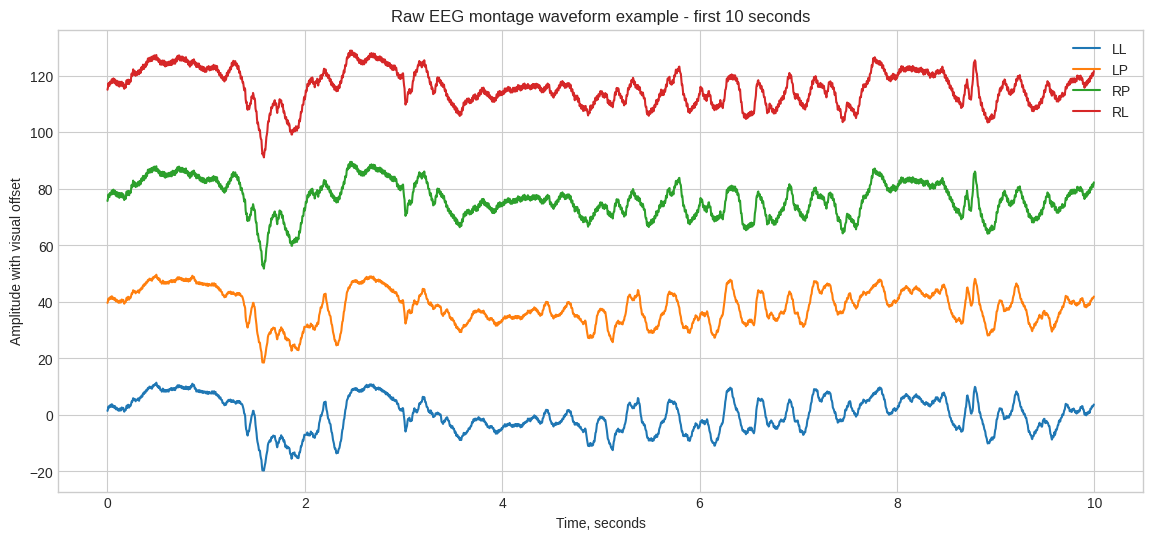

In [66]:
if "vote_sum" in train.columns:
    example_eeg_row = train[train["vote_sum"] >= 10].iloc[0]
else:
    example_eeg_row = train.iloc[0]

example_raw_eeg = load_raw_eeg(example_eeg_row["eeg_id"])
example_segment = crop_or_pad_eeg_segment(
    example_raw_eeg,
    offset_seconds=example_eeg_row["eeg_label_offset_seconds"],
)
example_montage = make_montage_signals(example_segment)

print("Example eeg_id:", int(example_eeg_row["eeg_id"]))
print("Offset seconds:", float(example_eeg_row["eeg_label_offset_seconds"]))
print("Segment shape:", example_segment.shape)
print("Target:", example_eeg_row["expert_consensus"])

plot_seconds = 10
plot_samples = plot_seconds * EEG_SAMPLE_RATE
time_axis = np.arange(plot_samples) / EEG_SAMPLE_RATE

plt.figure(figsize=(14, 6))
offset = 0
for group_name, signal in example_montage.items():
    visible = signal[:plot_samples]
    visible = visible - visible.mean()
    plt.plot(time_axis, visible + offset, label=group_name)
    offset += np.nanpercentile(np.abs(visible), 98) * 3

plt.title("Raw EEG montage waveform example - first 10 seconds")
plt.xlabel("Time, seconds")
plt.ylabel("Amplitude with visual offset")
plt.legend(loc="upper right")
plt.show()


### Create One EEG-Derived Spectrogram


In [67]:
def make_eeg_spectrogram_channel(signal, fs=EEG_SAMPLE_RATE, min_freq=0.5, max_freq=20.0):
    freqs, times, power = scipy_spectrogram(
        signal,
        fs=fs,
        nperseg=256,
        noverlap=128,
        nfft=512,
        scaling="density",
        mode="psd",
    )

    freq_mask = (freqs >= min_freq) & (freqs <= max_freq)
    power = power[freq_mask]
    freqs = freqs[freq_mask]

    image = np.log1p(power.astype(np.float32))
    image = (image - image.mean()) / (image.std() + 1e-6)
    return image, freqs, times


def make_eeg_derived_spectrogram(eeg_segment):
    montage = make_montage_signals(eeg_segment)
    images = []
    freq_values = None
    time_values = None

    for group_name in MONTAGE_GROUPS:
        image, freqs, times = make_eeg_spectrogram_channel(montage[group_name])
        images.append(image)
        freq_values = freqs
        time_values = times

    return np.stack(images, axis=0), freq_values, time_values


eeg_spec_image, eeg_spec_freqs, eeg_spec_times = make_eeg_derived_spectrogram(example_segment)

print("EEG-derived spectrogram shape:", eeg_spec_image.shape)
print("Format: [4 montage channels, frequency bins, time bins]")
print("Frequency range:", round(float(eeg_spec_freqs.min()), 2), "to", round(float(eeg_spec_freqs.max()), 2), "Hz")
print("Time range:", round(float(eeg_spec_times.min()), 2), "to", round(float(eeg_spec_times.max()), 2), "seconds")


EEG-derived spectrogram shape: (4, 50, 77)
Format: [4 montage channels, frequency bins, time bins]
Frequency range: 0.78 to 19.92 Hz
Time range: 0.64 to 49.28 seconds


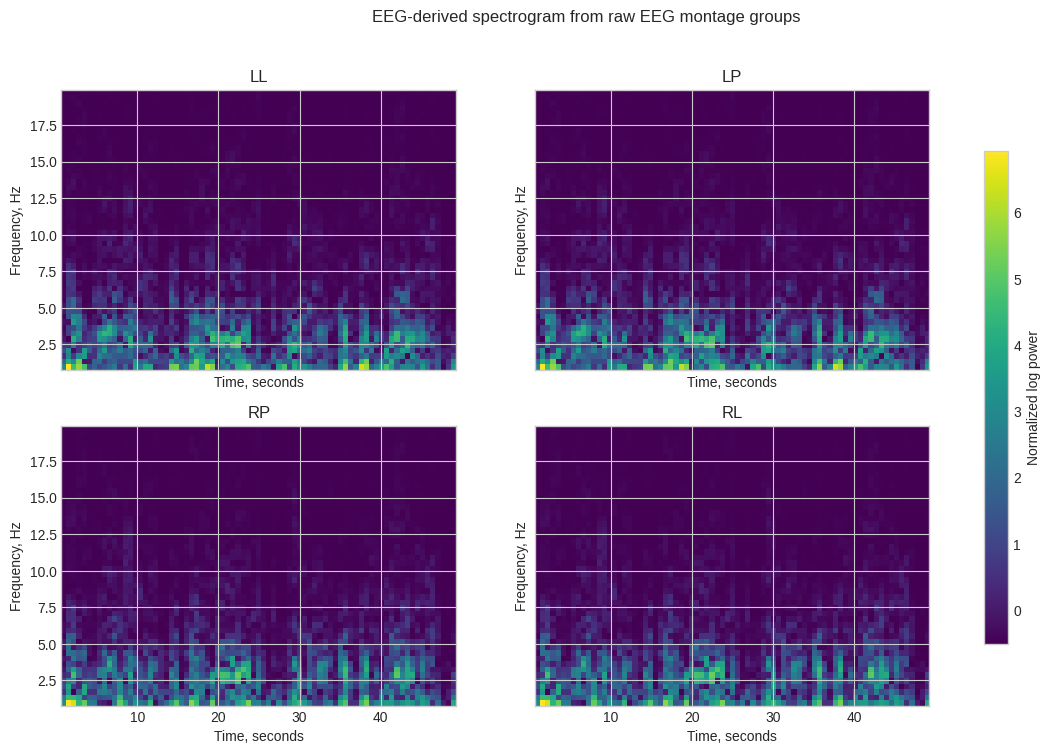

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, group_name, channel_image in zip(axes, MONTAGE_GROUPS.keys(), eeg_spec_image):
    im = ax.imshow(
        channel_image,
        aspect="auto",
        origin="lower",
        extent=[eeg_spec_times.min(), eeg_spec_times.max(), eeg_spec_freqs.min(), eeg_spec_freqs.max()],
        cmap="viridis",
    )
    ax.set_title(group_name)
    ax.set_xlabel("Time, seconds")
    ax.set_ylabel("Frequency, Hz")

fig.suptitle("EEG-derived spectrogram from raw EEG montage groups")
fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label="Normalized log power")
plt.show()


## 18. Raw EEG-Derived Spectrogram Model


In [69]:
from collections import OrderedDict

RAW_EEG_CACHE = OrderedDict()
EEG_SPEC_CACHE = OrderedDict()
MAX_RAW_EEG_CACHE_ITEMS = 256
MAX_EEG_SPEC_CACHE_ITEMS = 4096

EEG_SPEC_CHECKPOINT = "best_efficientnet_b0_eegspec_vote10_fold0.pt"

# Keep this separate from the previous experiments so we can quickly test first if needed.
EEG_SPEC_TRAIN_LIMIT = None
EEG_SPEC_VALID_LIMIT = None

print("Raw EEG spectrogram checkpoint:", EEG_SPEC_CHECKPOINT)


Raw EEG spectrogram checkpoint: best_efficientnet_b0_eegspec_vote10_fold0.pt


In [70]:
def load_raw_eeg_cached(eeg_id):
    eeg_id = int(eeg_id)
    if eeg_id in RAW_EEG_CACHE:
        RAW_EEG_CACHE.move_to_end(eeg_id)
        return RAW_EEG_CACHE[eeg_id]

    eeg_df = load_raw_eeg(eeg_id)
    RAW_EEG_CACHE[eeg_id] = eeg_df
    RAW_EEG_CACHE.move_to_end(eeg_id)

    while len(RAW_EEG_CACHE) > MAX_RAW_EEG_CACHE_ITEMS:
        RAW_EEG_CACHE.popitem(last=False)

    return eeg_df


def read_eeg_derived_spectrogram(eeg_id, offset_seconds):
    eeg_id = int(eeg_id)
    offset_seconds = float(offset_seconds)
    cache_key = (eeg_id, round(offset_seconds, 3))

    if cache_key in EEG_SPEC_CACHE:
        EEG_SPEC_CACHE.move_to_end(cache_key)
        return EEG_SPEC_CACHE[cache_key]

    eeg_df = load_raw_eeg_cached(eeg_id)
    eeg_segment = crop_or_pad_eeg_segment(eeg_df, offset_seconds=offset_seconds)
    image, _, _ = make_eeg_derived_spectrogram(eeg_segment)
    image = image.astype(np.float32)

    EEG_SPEC_CACHE[cache_key] = image
    EEG_SPEC_CACHE.move_to_end(cache_key)

    while len(EEG_SPEC_CACHE) > MAX_EEG_SPEC_CACHE_ITEMS:
        EEG_SPEC_CACHE.popitem(last=False)

    return image


In [71]:
class HmsEegSpectrogramDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def apply_spec_augment(self, image):
        if not self.augment:
            return image

        _, freq_bins, time_bins = image.shape

        if np.random.rand() < TIME_MASK_PROB:
            width = np.random.randint(1, min(TIME_MASK_MAX_WIDTH, time_bins) + 1)
            start = np.random.randint(0, max(1, time_bins - width + 1))
            image[:, :, start:start + width] = 0

        if np.random.rand() < FEATURE_MASK_PROB:
            width = np.random.randint(1, min(FEATURE_MASK_MAX_WIDTH, freq_bins) + 1)
            start = np.random.randint(0, max(1, freq_bins - width + 1))
            image[:, start:start + width, :] = 0

        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = read_eeg_derived_spectrogram(
            eeg_id=row["eeg_id"],
            offset_seconds=row["eeg_label_offset_seconds"],
        )
        image = self.apply_spec_augment(image.copy())
        image = torch.tensor(image, dtype=torch.float32)

        target = make_target(row)
        target = torch.tensor(target, dtype=torch.float32)
        return image, target


eegspec_train_df = expert_train_df if EEG_SPEC_TRAIN_LIMIT is None else expert_train_df.head(EEG_SPEC_TRAIN_LIMIT)
eegspec_valid_df = expert_valid_df if EEG_SPEC_VALID_LIMIT is None else expert_valid_df.head(EEG_SPEC_VALID_LIMIT)

eegspec_train_dataset = HmsEegSpectrogramDataset(eegspec_train_df, augment=True)
eegspec_valid_dataset = HmsEegSpectrogramDataset(eegspec_valid_df, augment=False)

eegspec_train_loader = DataLoader(
    eegspec_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

eegspec_valid_loader = DataLoader(
    eegspec_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

images, targets = next(iter(eegspec_train_loader))
print("images shape:", images.shape)
print("expected format: [batch, 4, frequency bins, time bins]")
print("targets shape:", targets.shape)


images shape: torch.Size([16, 4, 50, 77])
expected format: [batch, 4, frequency bins, time bins]
targets shape: torch.Size([16, 6])


### Raw EEG Spectrogram EfficientNet-B0


In [72]:
def create_eeg_spectrogram_model():
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    old_conv = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=4,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    with torch.no_grad():
        new_conv.weight[:, :3] = old_conv.weight
        new_conv.weight[:, 3:4] = old_conv.weight.mean(dim=1, keepdim=True)
    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=DROPOUT),
        nn.Linear(in_features, len(CLASS_NAMES)),
    )
    return model


def prepare_eeg_spectrogram_images(images):
    images = images.to(DEVICE, non_blocking=True)
    images = F.interpolate(images, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
    return images


In [73]:
def train_one_epoch_eegspec(model, loader, optimizer, scaler, epoch):
    model.train()
    losses = []
    progress = tqdm(loader, desc=f"Epoch {epoch} train EEG-spec", leave=False)

    for images, targets in progress:
        images = prepare_eeg_spectrogram_images(images)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = soft_cross_entropy_loss(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        losses.append(float(loss.detach().cpu()))
        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

    return float(np.mean(losses))


@torch.no_grad()
def validate_eegspec(model, loader, epoch):
    model.eval()
    losses = []
    all_targets = []
    all_probs = []
    progress = tqdm(loader, desc=f"Epoch {epoch} valid EEG-spec", leave=False)

    for images, targets in progress:
        images = prepare_eeg_spectrogram_images(images)
        targets = targets.to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = soft_cross_entropy_loss(logits, targets)
        probs = torch.softmax(logits.float(), dim=1)

        losses.append(float(loss.detach().cpu()))
        progress.set_postfix(loss=f"{np.mean(losses):.4f}")
        all_targets.append(targets.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(all_targets, axis=0)
    y_pred = np.concatenate(all_probs, axis=0)
    kl = kl_score_from_arrays(y_true, y_pred)
    return float(np.mean(losses)), kl


In [74]:
eegspec_model = create_eeg_spectrogram_model().to(DEVICE)
eegspec_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
eegspec_history = []
eegspec_best_valid_kl = float("inf")
eegspec_best_epoch = None


In [75]:
# Stage 1: frozen backbone
set_backbone_trainable(eegspec_model, trainable=False)
eegspec_optimizer = create_optimizer_for_current_stage(eegspec_model, lr=HEAD_LR)

for epoch in range(1, FREEZE_EPOCHS + 1):
    train_loss = train_one_epoch_eegspec(eegspec_model, eegspec_train_loader, eegspec_optimizer, eegspec_scaler, epoch)
    valid_loss, valid_kl = validate_eegspec(eegspec_model, eegspec_valid_loader, epoch)

    if valid_kl < eegspec_best_valid_kl:
        eegspec_best_valid_kl = valid_kl
        eegspec_best_epoch = epoch
        torch.save(
            {
                "model_state_dict": eegspec_model.state_dict(),
                "valid_kl": eegspec_best_valid_kl,
                "epoch": eegspec_best_epoch,
                "stage": "eegspec_frozen",
                "class_names": CLASS_NAMES,
                "input_type": "raw_eeg_derived_spectrogram_4ch",
            },
            EEG_SPEC_CHECKPOINT,
        )

    row = {
        "stage": "eegspec_frozen",
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_kl": valid_kl,
        "best_valid_kl": eegspec_best_valid_kl,
        "best_epoch": eegspec_best_epoch,
        "lr": HEAD_LR,
    }
    eegspec_history.append(row)
    print(row)


Epoch 1 train EEG-spec:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 1 valid EEG-spec:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'eegspec_frozen', 'epoch': 1, 'train_loss': 1.4865019759260736, 'valid_loss': 1.425926704497277, 'valid_kl': 0.7234690204068349, 'best_valid_kl': 0.7234690204068349, 'best_epoch': 1, 'lr': 0.0001}


In [76]:
# Stage 2: full fine-tune
set_backbone_trainable(eegspec_model, trainable=True)
eegspec_optimizer = create_optimizer_for_current_stage(eegspec_model, lr=BACKBONE_LR)
eegspec_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(eegspec_optimizer, T_max=UNFREEZE_EPOCHS)

for stage_epoch in range(1, UNFREEZE_EPOCHS + 1):
    epoch = FREEZE_EPOCHS + stage_epoch
    train_loss = train_one_epoch_eegspec(eegspec_model, eegspec_train_loader, eegspec_optimizer, eegspec_scaler, epoch)
    valid_loss, valid_kl = validate_eegspec(eegspec_model, eegspec_valid_loader, epoch)
    eegspec_scheduler.step()

    if valid_kl < eegspec_best_valid_kl:
        eegspec_best_valid_kl = valid_kl
        eegspec_best_epoch = epoch
        torch.save(
            {
                "model_state_dict": eegspec_model.state_dict(),
                "valid_kl": eegspec_best_valid_kl,
                "epoch": eegspec_best_epoch,
                "stage": "eegspec_full_finetune",
                "class_names": CLASS_NAMES,
                "input_type": "raw_eeg_derived_spectrogram_4ch",
            },
            EEG_SPEC_CHECKPOINT,
        )

    row = {
        "stage": "eegspec_full_finetune",
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_kl": valid_kl,
        "best_valid_kl": eegspec_best_valid_kl,
        "best_epoch": eegspec_best_epoch,
        "lr": eegspec_scheduler.get_last_lr()[0],
    }
    eegspec_history.append(row)
    print(row)


Epoch 2 train EEG-spec:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 2 valid EEG-spec:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'eegspec_full_finetune', 'epoch': 2, 'train_loss': 1.3117247242285568, 'valid_loss': 1.3114625032944016, 'valid_kl': 0.6090661753274872, 'best_valid_kl': 0.6090661753274872, 'best_epoch': 2, 'lr': 7.500000000000001e-06}


Epoch 3 train EEG-spec:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 3 valid EEG-spec:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'eegspec_full_finetune', 'epoch': 3, 'train_loss': 1.2367816571674384, 'valid_loss': 1.293918832268896, 'valid_kl': 0.5915430341272968, 'best_valid_kl': 0.5915430341272968, 'best_epoch': 3, 'lr': 2.5000000000000015e-06}


Epoch 4 train EEG-spec:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 4 valid EEG-spec:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'eegspec_full_finetune', 'epoch': 4, 'train_loss': 1.212463375673648, 'valid_loss': 1.3031728076783917, 'valid_kl': 0.6008043240665196, 'best_valid_kl': 0.5915430341272968, 'best_epoch': 3, 'lr': 0.0}


In [77]:
eegspec_history_df = pd.DataFrame(eegspec_history)
display(eegspec_history_df)
print("Best raw EEG spectrogram checkpoint:", EEG_SPEC_CHECKPOINT)
print("Best raw EEG spectrogram valid KL:", eegspec_best_valid_kl)


,stage,epoch,train_loss,valid_loss,valid_kl,best_valid_kl,best_epoch,lr
0,eegspec_frozen,1,1.486502,1.425927,0.723469,0.723469,1,0.000100
1,eegspec_full_finetune,2,1.311725,1.311463,0.609066,0.609066,2,0.000008
2,eegspec_full_finetune,3,1.236782,1.293919,0.591543,0.591543,3,0.000003
3,eegspec_full_finetune,4,1.212463,1.303173,0.600804,0.591543,3,0.000000


Best raw EEG spectrogram checkpoint: best_efficientnet_b0_eegspec_vote10_fold0.pt
Best raw EEG spectrogram valid KL: 0.5915430341272968


## Validation Ensemble Weight Search


In [78]:
@torch.no_grad()
def predict_fourch_validation(checkpoint_path=FOUR_CHANNEL_CHECKPOINT):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    model = create_four_channel_model().to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_targets = []
    all_probs = []

    for images, targets in tqdm(fourch_valid_loader, desc="Predict valid 4ch", leave=False):
        images = prepare_four_channel_images(images)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
        probs = torch.softmax(logits.float(), dim=1)

        all_targets.append(targets.numpy())
        all_probs.append(probs.detach().cpu().numpy())

    return np.concatenate(all_targets, axis=0), np.concatenate(all_probs, axis=0), checkpoint


@torch.no_grad()
def predict_eegspec_validation(checkpoint_path=EEG_SPEC_CHECKPOINT):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    model = create_eeg_spectrogram_model().to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_targets = []
    all_probs = []

    for images, targets in tqdm(eegspec_valid_loader, desc="Predict valid EEG-spec", leave=False):
        images = prepare_eeg_spectrogram_images(images)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
        probs = torch.softmax(logits.float(), dim=1)

        all_targets.append(targets.numpy())
        all_probs.append(probs.detach().cpu().numpy())

    return np.concatenate(all_targets, axis=0), np.concatenate(all_probs, axis=0), checkpoint


y_true_fourch, pred_fourch, fourch_checkpoint = predict_fourch_validation()
y_true_eegspec, pred_eegspec, eegspec_checkpoint = predict_eegspec_validation()

if not np.allclose(y_true_fourch, y_true_eegspec):
    raise ValueError("Validation targets are not aligned. Check dataloader order before ensembling.")

y_true = y_true_fourch

print("4ch checkpoint valid KL:", fourch_checkpoint.get("valid_kl"), "epoch:", fourch_checkpoint.get("epoch"))
print("EEG-spec checkpoint valid KL:", eegspec_checkpoint.get("valid_kl"), "epoch:", eegspec_checkpoint.get("epoch"))
print("validation predictions:", pred_fourch.shape, pred_eegspec.shape)


Predict valid 4ch:   0%|          | 0/395 [00:00<?, ?it/s]

Predict valid EEG-spec:   0%|          | 0/395 [00:00<?, ?it/s]

4ch checkpoint valid KL: 0.4980788842136798 epoch: 4
EEG-spec checkpoint valid KL: 0.5915430341272968 epoch: 3
validation predictions: (6318, 6) (6318, 6)


In [79]:
weight_rows = []

for fourch_weight in np.linspace(0, 1, 101):
    eegspec_weight = 1.0 - fourch_weight
    ensemble_pred = fourch_weight * pred_fourch + eegspec_weight * pred_eegspec
    ensemble_pred = ensemble_pred / ensemble_pred.sum(axis=1, keepdims=True)
    valid_kl = kl_score_from_arrays(y_true, ensemble_pred)

    weight_rows.append(
        {
            "fourch_weight": fourch_weight,
            "eegspec_weight": eegspec_weight,
            "valid_kl": valid_kl,
        }
    )

ensemble_weights_df = pd.DataFrame(weight_rows).sort_values("valid_kl").reset_index(drop=True)

print("Best validation ensemble weights:")
display(ensemble_weights_df.head(10))

BEST_FOURCH_WEIGHT = float(ensemble_weights_df.loc[0, "fourch_weight"])
BEST_EEGSPEC_WEIGHT = float(ensemble_weights_df.loc[0, "eegspec_weight"])
BEST_ENSEMBLE_VALID_KL = float(ensemble_weights_df.loc[0, "valid_kl"])

print("BEST_FOURCH_WEIGHT:", BEST_FOURCH_WEIGHT)
print("BEST_EEGSPEC_WEIGHT:", BEST_EEGSPEC_WEIGHT)
print("BEST_ENSEMBLE_VALID_KL:", BEST_ENSEMBLE_VALID_KL)


Best validation ensemble weights:


,fourch_weight,eegspec_weight,valid_kl
0,0.69,0.31,0.465771
1,0.68,0.32,0.465778
2,0.70,0.30,0.465813
3,0.67,0.33,0.465834
4,0.71,0.29,0.465905
5,0.66,0.34,0.465937
6,0.72,0.28,0.466046
7,0.65,0.35,0.466087
8,0.73,0.27,0.466239
9,0.64,0.36,0.466284


BEST_FOURCH_WEIGHT: 0.6900000000000001
BEST_EEGSPEC_WEIGHT: 0.30999999999999994
BEST_ENSEMBLE_VALID_KL: 0.46577134462553815


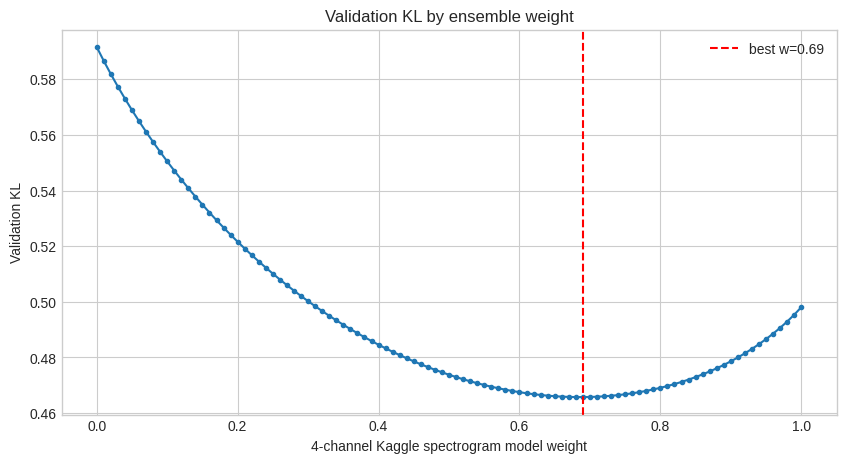

In [80]:
plt.figure(figsize=(10, 5))
plot_df = ensemble_weights_df.sort_values("fourch_weight")
plt.plot(plot_df["fourch_weight"], plot_df["valid_kl"], marker="o", markersize=3)
plt.axvline(BEST_FOURCH_WEIGHT, color="red", linestyle="--", label=f"best w={BEST_FOURCH_WEIGHT:.2f}")
plt.title("Validation KL by ensemble weight")
plt.xlabel("4-channel Kaggle spectrogram model weight")
plt.ylabel("Validation KL")
plt.legend()
plt.show()


In [81]:
ensemble_comparison = pd.DataFrame(
    [
        {
            "model": "4-channel Kaggle spectrogram",
            "fourch_weight": 1.0,
            "eegspec_weight": 0.0,
            "valid_kl": kl_score_from_arrays(y_true, pred_fourch),
        },
        {
            "model": "raw EEG-derived spectrogram",
            "fourch_weight": 0.0,
            "eegspec_weight": 1.0,
            "valid_kl": kl_score_from_arrays(y_true, pred_eegspec),
        },
        {
            "model": "validation-tuned ensemble",
            "fourch_weight": BEST_FOURCH_WEIGHT,
            "eegspec_weight": BEST_EEGSPEC_WEIGHT,
            "valid_kl": BEST_ENSEMBLE_VALID_KL,
        },
    ]
).sort_values("valid_kl")

display(ensemble_comparison)


,model,fourch_weight,eegspec_weight,valid_kl
2,validation-tuned ensemble,0.69,0.31,0.465771
0,4-channel Kaggle spectrogram,1.00,0.00,0.498079
1,raw EEG-derived spectrogram,0.00,1.00,0.591543


## Eight-Channel Combined Model

This experiment trains one model that sees both representations at the same time:

- 4 channels from Kaggle spectrograms: `LL`, `LP`, `RP`, `RL`;
- 4 channels from raw EEG-derived spectrograms: `LL`, `LP`, `RP`, `RL`.

So the model input becomes:

`[8 channels, 224, 224]`

In [82]:
class HmsCombinedSpectrogramDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def apply_kaggle_augment(self, image):
        if not self.augment:
            return image

        _, time_steps, n_features = image.shape

        if np.random.rand() < TIME_MASK_PROB:
            width = np.random.randint(1, min(TIME_MASK_MAX_WIDTH, time_steps) + 1)
            start = np.random.randint(0, max(1, time_steps - width + 1))
            image[:, start:start + width, :] = 0

        if np.random.rand() < FEATURE_MASK_PROB:
            width = np.random.randint(1, min(FEATURE_MASK_MAX_WIDTH, n_features) + 1)
            start = np.random.randint(0, max(1, n_features - width + 1))
            image[:, :, start:start + width] = 0

        return image

    def apply_eeg_augment(self, image):
        if not self.augment:
            return image

        _, freq_bins, time_bins = image.shape

        if np.random.rand() < TIME_MASK_PROB:
            width = np.random.randint(1, min(TIME_MASK_MAX_WIDTH, time_bins) + 1)
            start = np.random.randint(0, max(1, time_bins - width + 1))
            image[:, :, start:start + width] = 0

        if np.random.rand() < FEATURE_MASK_PROB:
            width = np.random.randint(1, min(FEATURE_MASK_MAX_WIDTH, freq_bins) + 1)
            start = np.random.randint(0, max(1, freq_bins - width + 1))
            image[:, start:start + width, :] = 0

        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        kaggle_image = read_four_channel_spectrogram(
            spectrogram_id=row["spectrogram_id"],
            offset_seconds=row["spectrogram_label_offset_seconds"],
        )
        eeg_image = read_eeg_derived_spectrogram(
            eeg_id=row["eeg_id"],
            offset_seconds=row["eeg_label_offset_seconds"],
        )

        kaggle_image = self.apply_kaggle_augment(kaggle_image.copy())
        eeg_image = self.apply_eeg_augment(eeg_image.copy())

        target = make_target(row)
        return (
            torch.tensor(kaggle_image, dtype=torch.float32),
            torch.tensor(eeg_image, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32),
        )


In [83]:
combined_train_dataset = HmsCombinedSpectrogramDataset(expert_train_df, augment=True)
combined_valid_dataset = HmsCombinedSpectrogramDataset(expert_valid_df, augment=False)

combined_train_loader = DataLoader(
    combined_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

combined_valid_loader = DataLoader(
    combined_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

kaggle_images, eeg_images, targets = next(iter(combined_train_loader))
print("kaggle images shape:", kaggle_images.shape)
print("eeg images shape:", eeg_images.shape)
print("targets shape:", targets.shape)


kaggle images shape: torch.Size([16, 4, 320, 100])
eeg images shape: torch.Size([16, 4, 50, 77])
targets shape: torch.Size([16, 6])


In [84]:
COMBINED_CHECKPOINT = "best_efficientnet_b0_combined_8ch_vote10_fold0.pt"


def create_combined_model():
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    old_conv = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=8,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    with torch.no_grad():
        new_conv.weight[:, :3] = old_conv.weight
        mean_weight = old_conv.weight.mean(dim=1, keepdim=True)
        new_conv.weight[:, 3:] = mean_weight.repeat(1, 5, 1, 1)
    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=DROPOUT),
        nn.Linear(in_features, len(CLASS_NAMES)),
    )
    return model


def prepare_combined_images(kaggle_images, eeg_images):
    kaggle_images = kaggle_images.to(DEVICE, non_blocking=True)
    eeg_images = eeg_images.to(DEVICE, non_blocking=True)

    kaggle_images = F.interpolate(kaggle_images, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
    eeg_images = F.interpolate(eeg_images, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)

    return torch.cat([kaggle_images, eeg_images], dim=1)


In [85]:
def train_one_epoch_combined(model, loader, optimizer, scaler, epoch):
    model.train()
    losses = []
    progress = tqdm(loader, desc=f"Epoch {epoch} train combined 8ch", leave=False)

    for kaggle_images, eeg_images, targets in progress:
        images = prepare_combined_images(kaggle_images, eeg_images)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = soft_cross_entropy_loss(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        losses.append(float(loss.detach().cpu()))
        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

    return float(np.mean(losses))


@torch.no_grad()
def validate_combined(model, loader, epoch):
    model.eval()
    losses = []
    all_targets = []
    all_probs = []
    progress = tqdm(loader, desc=f"Epoch {epoch} valid combined 8ch", leave=False)

    for kaggle_images, eeg_images, targets in progress:
        images = prepare_combined_images(kaggle_images, eeg_images)
        targets = targets.to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = soft_cross_entropy_loss(logits, targets)
        probs = torch.softmax(logits.float(), dim=1)

        losses.append(float(loss.detach().cpu()))
        progress.set_postfix(loss=f"{np.mean(losses):.4f}")
        all_targets.append(targets.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(all_targets, axis=0)
    y_pred = np.concatenate(all_probs, axis=0)
    kl = kl_score_from_arrays(y_true, y_pred)
    return float(np.mean(losses)), kl


In [86]:
combined_model = create_combined_model().to(DEVICE)
combined_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
combined_history = []
combined_best_valid_kl = float("inf")
combined_best_epoch = None

print("Combined checkpoint:", COMBINED_CHECKPOINT)


Combined checkpoint: best_efficientnet_b0_combined_8ch_vote10_fold0.pt


In [87]:
# Stage 1: frozen backbone
set_backbone_trainable(combined_model, trainable=False)
combined_optimizer = create_optimizer_for_current_stage(combined_model, lr=HEAD_LR)

for epoch in range(1, FREEZE_EPOCHS + 1):
    train_loss = train_one_epoch_combined(combined_model, combined_train_loader, combined_optimizer, combined_scaler, epoch)
    valid_loss, valid_kl = validate_combined(combined_model, combined_valid_loader, epoch)

    if valid_kl < combined_best_valid_kl:
        combined_best_valid_kl = valid_kl
        combined_best_epoch = epoch
        torch.save(
            {
                "model_state_dict": combined_model.state_dict(),
                "valid_kl": combined_best_valid_kl,
                "epoch": combined_best_epoch,
                "stage": "combined_frozen",
                "class_names": CLASS_NAMES,
                "input_type": "kaggle_4ch_plus_raw_eeg_4ch",
            },
            COMBINED_CHECKPOINT,
        )

    row = {
        "stage": "combined_frozen",
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_kl": valid_kl,
        "best_valid_kl": combined_best_valid_kl,
        "best_epoch": combined_best_epoch,
        "lr": HEAD_LR,
    }
    combined_history.append(row)
    print(row)


Epoch 1 train combined 8ch:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 1 valid combined 8ch:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'combined_frozen', 'epoch': 1, 'train_loss': 1.4918294914215662, 'valid_loss': 1.4540292822861973, 'valid_kl': 0.7515480029309612, 'best_valid_kl': 0.7515480029309612, 'best_epoch': 1, 'lr': 0.0001}


In [88]:
# Stage 2: full fine-tune
set_backbone_trainable(combined_model, trainable=True)
combined_optimizer = create_optimizer_for_current_stage(combined_model, lr=BACKBONE_LR)
combined_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(combined_optimizer, T_max=UNFREEZE_EPOCHS)

for stage_epoch in range(1, UNFREEZE_EPOCHS + 1):
    epoch = FREEZE_EPOCHS + stage_epoch
    train_loss = train_one_epoch_combined(combined_model, combined_train_loader, combined_optimizer, combined_scaler, epoch)
    valid_loss, valid_kl = validate_combined(combined_model, combined_valid_loader, epoch)
    combined_scheduler.step()

    if valid_kl < combined_best_valid_kl:
        combined_best_valid_kl = valid_kl
        combined_best_epoch = epoch
        torch.save(
            {
                "model_state_dict": combined_model.state_dict(),
                "valid_kl": combined_best_valid_kl,
                "epoch": combined_best_epoch,
                "stage": "combined_full_finetune",
                "class_names": CLASS_NAMES,
                "input_type": "kaggle_4ch_plus_raw_eeg_4ch",
            },
            COMBINED_CHECKPOINT,
        )

    row = {
        "stage": "combined_full_finetune",
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_kl": valid_kl,
        "best_valid_kl": combined_best_valid_kl,
        "best_epoch": combined_best_epoch,
        "lr": combined_scheduler.get_last_lr()[0],
    }
    combined_history.append(row)
    print(row)


Epoch 2 train combined 8ch:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 2 valid combined 8ch:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'combined_full_finetune', 'epoch': 2, 'train_loss': 1.2577005843113538, 'valid_loss': 1.2504852057257785, 'valid_kl': 0.5480313173319781, 'best_valid_kl': 0.5480313173319781, 'best_epoch': 2, 'lr': 7.500000000000001e-06}


Epoch 3 train combined 8ch:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 3 valid combined 8ch:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'combined_full_finetune', 'epoch': 3, 'train_loss': 1.1641513024989363, 'valid_loss': 1.2263529328605798, 'valid_kl': 0.5239166206025966, 'best_valid_kl': 0.5239166206025966, 'best_epoch': 3, 'lr': 2.5000000000000015e-06}


Epoch 4 train combined 8ch:   0%|          | 0/2102 [00:00<?, ?it/s]

Epoch 4 valid combined 8ch:   0%|          | 0/395 [00:00<?, ?it/s]

{'stage': 'combined_full_finetune', 'epoch': 4, 'train_loss': 1.1311560900408693, 'valid_loss': 1.2095264277126216, 'valid_kl': 0.5070809152431703, 'best_valid_kl': 0.5070809152431703, 'best_epoch': 4, 'lr': 0.0}


In [89]:
combined_history_df = pd.DataFrame(combined_history)
display(combined_history_df)
print("Best combined checkpoint:", COMBINED_CHECKPOINT)
print("Best combined valid KL:", combined_best_valid_kl)


,stage,epoch,train_loss,valid_loss,valid_kl,best_valid_kl,best_epoch,lr
0,combined_frozen,1,1.491829,1.454029,0.751548,0.751548,1,0.000100
1,combined_full_finetune,2,1.257701,1.250485,0.548031,0.548031,2,0.000008
2,combined_full_finetune,3,1.164151,1.226353,0.523917,0.523917,3,0.000003
3,combined_full_finetune,4,1.131156,1.209526,0.507081,0.507081,4,0.000000


Best combined checkpoint: best_efficientnet_b0_combined_8ch_vote10_fold0.pt
Best combined valid KL: 0.5070809152431703


## Three-Model Validation Ensemble Weight Search


In [90]:
@torch.no_grad()
def predict_combined_validation(checkpoint_path=COMBINED_CHECKPOINT):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    model = create_combined_model().to(DEVICE)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_targets = []
    all_probs = []

    for kaggle_images, eeg_images, targets in tqdm(combined_valid_loader, desc="Predict valid combined 8ch", leave=False):
        images = prepare_combined_images(kaggle_images, eeg_images)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
        probs = torch.softmax(logits.float(), dim=1)

        all_targets.append(targets.numpy())
        all_probs.append(probs.detach().cpu().numpy())

    return np.concatenate(all_targets, axis=0), np.concatenate(all_probs, axis=0), checkpoint


# Reuse predictions from section 19 if they already exist; otherwise compute them now.
if "pred_fourch" not in globals() or "pred_eegspec" not in globals() or "y_true" not in globals():
    y_true_fourch, pred_fourch, fourch_checkpoint = predict_fourch_validation()
    y_true_eegspec, pred_eegspec, eegspec_checkpoint = predict_eegspec_validation()
    if not np.allclose(y_true_fourch, y_true_eegspec):
        raise ValueError("4ch and EEG-spec validation targets are not aligned.")
    y_true = y_true_fourch

y_true_combined, pred_combined, combined_checkpoint = predict_combined_validation()

if not np.allclose(y_true, y_true_combined):
    raise ValueError("Combined validation targets are not aligned with previous validation predictions.")

print("4ch valid KL:", kl_score_from_arrays(y_true, pred_fourch))
print("EEG-spec valid KL:", kl_score_from_arrays(y_true, pred_eegspec))
print("Combined 8ch checkpoint valid KL:", combined_checkpoint.get("valid_kl"), "epoch:", combined_checkpoint.get("epoch"))
print("Combined 8ch recalculated valid KL:", kl_score_from_arrays(y_true, pred_combined))


Predict valid combined 8ch:   0%|          | 0/395 [00:00<?, ?it/s]

4ch valid KL: 0.4980788842136798
EEG-spec valid KL: 0.5915430341272968
Combined 8ch checkpoint valid KL: 0.5070809152431703 epoch: 4
Combined 8ch recalculated valid KL: 0.5070809152431703


In [92]:
WEIGHT_GRID_DENOMINATOR = 100
three_model_rows = []

for w_fourch_int in range(WEIGHT_GRID_DENOMINATOR + 1):
    for w_eegspec_int in range(WEIGHT_GRID_DENOMINATOR + 1 - w_fourch_int):
        w_fourch = w_fourch_int / WEIGHT_GRID_DENOMINATOR
        w_eegspec = w_eegspec_int / WEIGHT_GRID_DENOMINATOR
        w_combined = 1.0 - w_fourch - w_eegspec

        ensemble_pred = (
            w_fourch * pred_fourch
            + w_eegspec * pred_eegspec
            + w_combined * pred_combined
        )
        ensemble_pred = ensemble_pred / ensemble_pred.sum(axis=1, keepdims=True)
        valid_kl = kl_score_from_arrays(y_true, ensemble_pred)

        three_model_rows.append(
            {
                "fourch_weight": w_fourch,
                "eegspec_weight": w_eegspec,
                "combined_weight": w_combined,
                "valid_kl": valid_kl,
            }
        )

three_model_weights_df = pd.DataFrame(three_model_rows).sort_values("valid_kl").reset_index(drop=True)

print("Best 3-model validation ensemble weights:")
display(three_model_weights_df.head(15))

BEST_3M_FOURCH_WEIGHT = float(three_model_weights_df.loc[0, "fourch_weight"])
BEST_3M_EEGSPEC_WEIGHT = float(three_model_weights_df.loc[0, "eegspec_weight"])
BEST_3M_COMBINED_WEIGHT = float(three_model_weights_df.loc[0, "combined_weight"])
BEST_3M_VALID_KL = float(three_model_weights_df.loc[0, "valid_kl"])

print("BEST_3M_FOURCH_WEIGHT:", BEST_3M_FOURCH_WEIGHT)
print("BEST_3M_EEGSPEC_WEIGHT:", BEST_3M_EEGSPEC_WEIGHT)
print("BEST_3M_COMBINED_WEIGHT:", BEST_3M_COMBINED_WEIGHT)
print("BEST_3M_VALID_KL:", BEST_3M_VALID_KL)


Best 3-model validation ensemble weights:


,fourch_weight,eegspec_weight,combined_weight,valid_kl
0,0.48,0.22,0.30,0.457026
1,0.47,0.22,0.31,0.457033
2,0.47,0.23,0.30,0.457034
3,0.48,0.23,0.29,0.457036
4,0.49,0.22,0.29,0.457042
5,0.46,0.23,0.31,0.457055
6,0.49,0.23,0.28,0.457059
7,0.46,0.22,0.32,0.457061
8,0.48,0.21,0.31,0.457061
9,0.49,0.21,0.30,0.457069


BEST_3M_FOURCH_WEIGHT: 0.48
BEST_3M_EEGSPEC_WEIGHT: 0.22
BEST_3M_COMBINED_WEIGHT: 0.30000000000000004
BEST_3M_VALID_KL: 0.4570263626741931


In [93]:
two_model_pred = BEST_FOURCH_WEIGHT * pred_fourch + BEST_EEGSPEC_WEIGHT * pred_eegspec
two_model_pred = two_model_pred / two_model_pred.sum(axis=1, keepdims=True)

three_model_comparison = pd.DataFrame(
    [
        {
            "model": "4-channel Kaggle spectrogram",
            "fourch_weight": 1.0,
            "eegspec_weight": 0.0,
            "combined_weight": 0.0,
            "valid_kl": kl_score_from_arrays(y_true, pred_fourch),
        },
        {
            "model": "raw EEG-derived spectrogram",
            "fourch_weight": 0.0,
            "eegspec_weight": 1.0,
            "combined_weight": 0.0,
            "valid_kl": kl_score_from_arrays(y_true, pred_eegspec),
        },
        {
            "model": "8-channel combined",
            "fourch_weight": 0.0,
            "eegspec_weight": 0.0,
            "combined_weight": 1.0,
            "valid_kl": kl_score_from_arrays(y_true, pred_combined),
        },
        {
            "model": "2-model ensemble",
            "fourch_weight": BEST_FOURCH_WEIGHT,
            "eegspec_weight": BEST_EEGSPEC_WEIGHT,
            "combined_weight": 0.0,
            "valid_kl": kl_score_from_arrays(y_true, two_model_pred),
        },
        {
            "model": "3-model ensemble",
            "fourch_weight": BEST_3M_FOURCH_WEIGHT,
            "eegspec_weight": BEST_3M_EEGSPEC_WEIGHT,
            "combined_weight": BEST_3M_COMBINED_WEIGHT,
            "valid_kl": BEST_3M_VALID_KL,
        },
    ]
).sort_values("valid_kl")

display(three_model_comparison)


,model,fourch_weight,eegspec_weight,combined_weight,valid_kl
4,3-model ensemble,0.48,0.22,0.3,0.457026
3,2-model ensemble,0.69,0.31,0.0,0.465771
0,4-channel Kaggle spectrogram,1.00,0.00,0.0,0.498079
2,8-channel combined,0.00,0.00,1.0,0.507081
1,raw EEG-derived spectrogram,0.00,1.00,0.0,0.591543


## Final Results Summary


In [94]:
final_results = pd.DataFrame(
    [
        {
            "experiment": "EfficientNet-B0, 1-channel",
            "input": "Kaggle spectrograms, all rows",
            "cv_kl": 0.751706,
            "public_lb": 0.654968,
            "private_lb": 0.775138,
        },
        {
            "experiment": "EfficientNet-B0, freeze/unfreeze",
            "input": "Kaggle spectrograms, all rows",
            "cv_kl": 0.741544,
            "public_lb": 0.696741,
            "private_lb": 0.808924,
        },
        {
            "experiment": "EfficientNet-B0, expert-only",
            "input": "Kaggle spectrograms, vote_sum >= 10",
            "cv_kl": 0.556609,
            "public_lb": 0.610846,
            "private_lb": 0.701319,
        },
        {
            "experiment": "4-channel Kaggle spectrogram",
            "input": "LL/LP/RP/RL Kaggle spectrograms, vote_sum >= 10",
            "cv_kl": 0.498079,
            "public_lb": 0.591182,
            "private_lb": 0.674380,
        },
        {
            "experiment": "Raw EEG-derived spectrogram",
            "input": "Raw EEG -> montage spectrograms, vote_sum >= 10",
            "cv_kl": 0.591543,
            "public_lb": 0.582554,
            "private_lb": 0.649420,
        },
        {
            "experiment": "8-channel combined",
            "input": "4ch Kaggle + 4ch raw EEG in one model",
            "cv_kl": 0.507081,
            "public_lb": 0.564549,
            "private_lb": 0.625351,
        },
        {
            "experiment": "2-model ensemble",
            "input": "0.69 * 4ch Kaggle + 0.31 * raw EEG",
            "cv_kl": 0.465771,
            "public_lb": 0.528763,
            "private_lb": 0.598507,
        },
        {
            "experiment": "3-model ensemble",
            "input": "0.48 * 4ch Kaggle + 0.22 * raw EEG + 0.30 * 8ch combined",
            "cv_kl": 0.457026,
            "public_lb": 0.516711,
            "private_lb": 0.583334,
        },
    ]
)

final_results = final_results.sort_values("private_lb").reset_index(drop=True)
final_results.insert(0, "rank", np.arange(1, len(final_results) + 1))

styled_final_results = (
    final_results.style
    .format({"cv_kl": "{:.6f}", "public_lb": "{:.6f}", "private_lb": "{:.6f}"})
    .background_gradient(subset=["cv_kl", "public_lb", "private_lb"], cmap="Greens_r")
)

display(styled_final_results)


,rank,experiment,input,cv_kl,public_lb,private_lb
0,1,3-model ensemble,0.48 * 4ch Kaggle + 0.22 * raw EEG + 0.30 * 8ch combined,0.457026,0.516711,0.583334
1,2,2-model ensemble,0.69 * 4ch Kaggle + 0.31 * raw EEG,0.465771,0.528763,0.598507
2,3,8-channel combined,4ch Kaggle + 4ch raw EEG in one model,0.507081,0.564549,0.625351
3,4,Raw EEG-derived spectrogram,"Raw EEG -> montage spectrograms, vote_sum >= 10",0.591543,0.582554,0.649420
4,5,4-channel Kaggle spectrogram,"LL/LP/RP/RL Kaggle spectrograms, vote_sum >= 10",0.498079,0.591182,0.674380
5,6,"EfficientNet-B0, expert-only","Kaggle spectrograms, vote_sum >= 10",0.556609,0.610846,0.701319
6,7,"EfficientNet-B0, 1-channel","Kaggle spectrograms, all rows",0.751706,0.654968,0.775138
7,8,"EfficientNet-B0, freeze/unfreeze","Kaggle spectrograms, all rows",0.741544,0.696741,0.808924
